# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2, transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from itertools import product, combinations
from collections import Counter

# ── Stats ────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── Other ML ─────────────────────────────────────────────
from lightgbm import LGBMClassifier
import joblib

# ── NLTK ─────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoConfig,
    AutoTokenizer,
    AlbertForSequenceClassification,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# ── Notebook setup ───────────────────────────────────────
# %matplotlib inline
warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

## 1.2 Seeds \& Device

In [6]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

USE_FP16 = DEVICE.type == "cuda"
TORCH_COMPILE_OK = hasattr(torch, "compile") and DEVICE.type == "cuda"

Device: cpu


## 1.3 Configuration

In [ ]:
REPO_ROOT = Path(os.environ.get("MENTALHEALTH_REPO_ROOT", Path.cwd())).expanduser().resolve()
DATA_ROOT = Path(os.environ.get("MENTALHEALTH_DATA_ROOT", REPO_ROOT / "0. Dataset")).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get("MENTALHEALTH_OUTPUT_ROOT", REPO_ROOT / "outputs")).expanduser().resolve()
RAW_DATA_FILE = "mental_health_unified_labels_final.csv"
OUTPUT_DIR = "01_OriginalLabel"

TEXT_COLUMN = "statement"
LABEL_COLUMN = "status"
LABEL_COLUMN_ENCODED = "Status_Encoded" # For our new numeric labels

# Explicit ordinal class order (NOT alphabetical)
CLASS_NAMES = ["Anxiety", "Normal", "Depression", "Suicidal", "Stress", "Bipolar", "Personality disorder"]
NUM_CLASSES = len(CLASS_NAMES)

# Training settings
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
SEQ_MAX_GRAD_NORM = 5.0
MAX_GRAD_NORM = 1.0

# ── Model file paths ────────────────────────────────────
OUTPUT_PATH = OUTPUT_ROOT / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "lr":      {"model": OUTPUT_PATH / "best_lr_model.joblib",   "params": OUTPUT_PATH / "best_lr_params.json"},
    "svm":     {"model": OUTPUT_PATH / "best_svm_model.joblib",  "params": OUTPUT_PATH / "best_svm_params.json"},
    "rf":      {"model": OUTPUT_PATH / "best_rf_model.joblib",   "params": OUTPUT_PATH / "best_rf_params.json"},
    "lgbm":    {"model": OUTPUT_PATH / "best_lgbm_model.joblib", "params": OUTPUT_PATH / "best_lgbm_params.json"},
    "gru":     {"model": OUTPUT_PATH / "best_gru_model.pth",     "params": OUTPUT_PATH / "best_gru_params.json"},
    "cnn":     {"model": OUTPUT_PATH / "best_cnn_model.pth",     "params": OUTPUT_PATH / "best_cnn_params.json"},
    "albert":  {"model": OUTPUT_PATH / "best_albert_model.pth",  "params": OUTPUT_PATH / "best_albert_params.json"},
    "biobert": {"model": OUTPUT_PATH / "best_biobert_model.pth", "params": OUTPUT_PATH / "best_biobert_params.json"},
}

RAW_DATA_PATH = DATA_ROOT / "analysis_ready" / RAW_DATA_FILE

print("--- Configuration Loaded ---")
print(f"  Output  : {OUTPUT_PATH}")
print(f"  Classes : {CLASS_NAMES}")
print(f"  FP16    : {USE_FP16}")

## 1.4 Mount drive \& Load the data

In [ ]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {RAW_DATA_PATH}. Download the OSF data package "
        "into 0. Dataset/ or set MENTALHEALTH_DATA_ROOT."
    )

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]} rows.")

df_raw.head()


# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [9]:
# Shuffle
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)
df_raw

## 2.2 Master Data Preparation

In [10]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


In [11]:
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(CLASS_NAMES)  # force ordinal order
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.transform(df_clean[LABEL_COLUMN])

print(f"Label mapping: {dict(zip(CLASS_NAMES, range(NUM_CLASSES)))}")
print(f"df_clean: {df_clean.shape[0]} rows")


Label mapping: {'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}
df_clean: 53043 rows


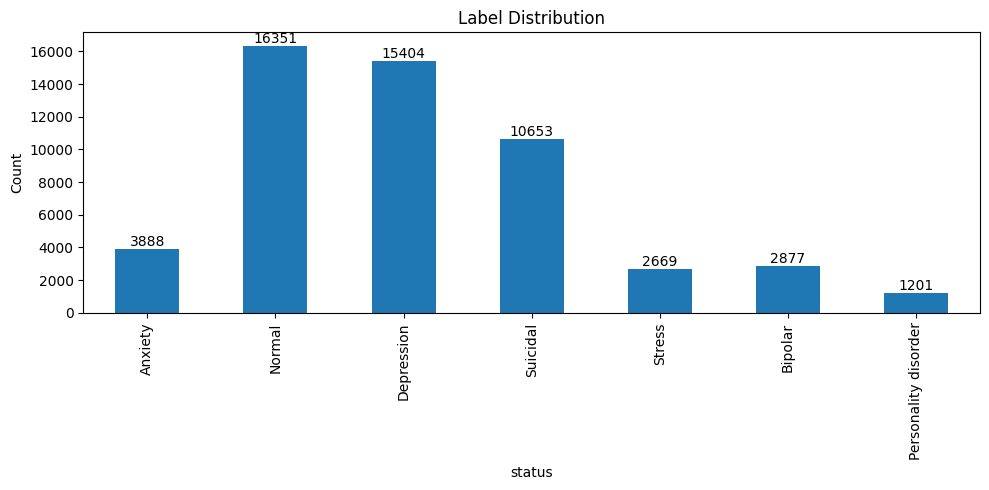

In [12]:
plt.figure(figsize=(10, 5))
counts = df_clean[LABEL_COLUMN].value_counts().reindex(CLASS_NAMES)
ax = counts.plot(kind="bar")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Label Distribution")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

In [13]:
groups = df_clean[TEXT_COLUMN]
y = df_clean[LABEL_COLUMN_ENCODED]

# 80/20 → trainval / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# 75/25 of trainval → train / val (≈60/20/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval[LABEL_COLUMN_ENCODED], groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("Split counts:")
print(df_clean["split"].value_counts())

# Leakage check
n_leaky = (df_clean.groupby(TEXT_COLUMN)["split"].nunique() > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print(f"Leakage check passed.")

print("Split proportions:")
print(df_clean["split"].value_counts(normalize=True))

# Save master split
split_path = OUTPUT_PATH / "MentalHealth_master_split.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")

Split counts:
split
train    31976
test     10550
val      10517
Name: count, dtype: int64
Leakage check passed.
Split proportions:
split
train    0.602832
test     0.198895
val      0.198273
Name: proportion, dtype: float64
Saved → outputs/01_OriginalLabel/MentalHealth_master_split.csv


## 2.4 Shared helper functions

### 2.4.1 Bootstrap CI

In [14]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    """Return the OBSERVED F1 on the full test set plus a bootstrap 95% CI.

    The first element is the direct point estimate, not the mean of the
    bootstrap replicates; replicates are used only for the interval.
    """
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    observed = f1_score(y_true, y_pred, average=average)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return observed, np.nan, np.nan
    return observed, np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    """Observed macro AUC plus a bootstrap 95% CI (point estimate is direct)."""
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    try:
        observed = roc_auc_score(y_true, y_scores, average=average, multi_class="ovr")
    except Exception:
        observed = np.nan
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return observed, np.nan, np.nan
    return observed, np.percentile(scores, 2.5), np.percentile(scores, 97.5)

### 2.4.2 Plotting

In [15]:
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, classes_list, title="Model", save_dir=None):
    """Works for both string and int class lists."""
    y_true_bin = label_binarize(y_true, classes=classes_list)
    n_classes = len(classes_list)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (cls, color) in enumerate(zip(classes_list, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{cls} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

### 2.4.3 Machine Learning Evaluation Wrapper

In [16]:
def evaluate_ml(model, X_test, y_test, model_name="Model"):
    """Full evaluation for a fitted sklearn classifier."""
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    y_pred = model.predict(X_test)
    classes = model.classes_

    print(classification_report(y_test, y_pred, digits=4, labels=classes))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_test, y_pred)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    f1_mac, f1_mac_lo, f1_mac_hi = bootstrap_f1_ci(y_test, y_pred, average="macro")
    print(f"Macro F1:    {f1_mac:.4f}  95% CI [{f1_mac_lo:.4f}, {f1_mac_hi:.4f}]")

    plot_confusion_matrix(y_test, y_pred, labels=classes,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("No probability scores available.")
        return

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_test, y_scores)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(y_test, y_scores, classes,
                       title=model_name, save_dir=str(OUTPUT_PATH))

### 2.4.4 PyTorch Evaluation Wrapper

In [17]:
@torch.no_grad()
def evaluate_pytorch(model, test_loader, label_encoder, model_name="Model",
                     use_attention_mask=True):
    """Full evaluation for a PyTorch classifier."""
    model.eval().to(DEVICE)
    all_preds, all_probs, all_labels = [], [], []

    for batch in tqdm(test_loader, desc=f"Eval {model_name}"):
        ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if use_attention_mask:
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
        else:
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    classes_str = label_encoder.classes_
    classes_int = np.arange(NUM_CLASSES)

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    print(classification_report(all_labels, all_preds,
                                target_names=classes_str, digits=4))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(all_labels, all_preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    f1_mac, f1_mac_lo, f1_mac_hi = bootstrap_f1_ci(all_labels, all_preds, average="macro")
    print(f"Macro F1:    {f1_mac:.4f}  95% CI [{f1_mac_lo:.4f}, {f1_mac_hi:.4f}]")

    plot_confusion_matrix(all_labels, all_preds, labels=classes_int,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(all_labels, all_probs)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(all_labels, all_probs, classes_int,
                       title=model_name, save_dir=str(OUTPUT_PATH))

    return all_preds, all_probs, all_labels

### 2.4.5 Machine Learning Feature Importance (shared)

In [18]:
def plot_feature_importance(importances, feature_names, model_name="Model", top_n=20):
    """Generic feature importance plot for any ML model."""
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp["Scaled"] = (df_imp["Importance"] / df_imp["Importance"].max()) * 100
    top = df_imp.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x="Scaled", y="Feature", data=top[::-1], palette="mako")
    plt.title(f"Top {top_n} Feature Importance ({model_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Relative Importance (%)")
    plt.ylabel("Feature")
    plt.tight_layout()

    path = OUTPUT_PATH / f"{model_name.lower().replace(' ', '_')}_feature_importance.png"
    plt.savefig(path, dpi=300)
    print(f"Saved → {path}")
    plt.show()

    return top

# 3. Classical ML Modeling

## 3.0 Pre-processing for classical ML Models


In [19]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def ml_preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(tokens)


df_ml = df_clean.copy()
df_ml["text_ml"] = df_ml[TEXT_COLUMN].apply(ml_preprocess)

df_train_ml = df_ml[df_ml["split"] == "train"].copy()
df_val_ml   = df_ml[df_ml["split"] == "val"].copy()
df_test_ml  = df_ml[df_ml["split"] == "test"].copy()

X_train_ml = df_train_ml["text_ml"].tolist()
X_val_ml   = df_val_ml["text_ml"].tolist()
X_test_ml  = df_test_ml["text_ml"].tolist()

y_train_ml = df_train_ml[LABEL_COLUMN].astype(str).values
y_val_ml   = df_val_ml[LABEL_COLUMN].astype(str).values
y_test_ml  = df_test_ml[LABEL_COLUMN].astype(str).values

# TF-IDF (no stop_words param — already removed in ml_preprocess)
tfidf = TfidfVectorizer(max_features=VOCAB_SIZE)
X_train_tfidf = tfidf.fit_transform(X_train_ml)
X_val_tfidf   = tfidf.transform(X_val_ml)
X_test_tfidf  = tfidf.transform(X_test_ml)

print(f"TF-IDF: train={X_train_tfidf.shape}, val={X_val_tfidf.shape}, test={X_test_tfidf.shape}")
feature_names_tfidf = tfidf.get_feature_names_out()

print(f"ML splits: train={len(df_train_ml)}, val={len(df_val_ml)}, test={len(df_test_ml)}")

TF-IDF: train=(31976, 10000), val=(10517, 10000), test=(10550, 10000)
ML splits: train=31976, val=10517, test=10550


## 3.1 Logistic Regression

### Step 1: Hyperparameter Tuning

In [20]:
RETRAIN = True
if RETRAIN:
    # 7.1 Hyperparameter Tuning (grid search)
    set_seed()
    print("Tuning Logistic Regression...")
    start = time.time()

    lr_grid = {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "saga"],
        "class_weight": ["balanced", None],
    }

    best_f1_lr, best_model_lr, best_params_lr = 0, None, None

    for C, solver, cw in product(lr_grid["C"], lr_grid["solver"], lr_grid["class_weight"]):
        try:
            model = LogisticRegression(
                C=C, solver=solver, penalty="l2", multi_class="multinomial",
                class_weight=cw, max_iter=1000, random_state=RANDOM_STATE,
                n_jobs=-1 if solver == "saga" else None,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lr:
                best_f1_lr = f1
                best_model_lr = model
                best_params_lr = {"C": C, "solver": solver, "class_weight": cw}
                print(f"  LR F1={f1:.4f} | {best_params_lr}")
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LR tuning: {time.time()-start:.1f}s | Best F1={best_f1_lr:.4f}")

    joblib.dump(best_model_lr, MODEL_PATHS["lr"]["model"])
    with open(MODEL_PATHS["lr"]["params"], "w") as f:
        json.dump(best_params_lr, f, indent=2)
else:
    print("Loading LR from disk...")
    best_model_lr = joblib.load(MODEL_PATHS["lr"]["model"])
    print(f"Loaded LR from {MODEL_PATHS['lr']['model']}")

Tuning Logistic Regression...
  LR F1=0.7135 | {'C': 0.1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.7135 | {'C': 0.1, 'solver': 'saga', 'class_weight': 'balanced'}
  LR F1=0.7336 | {'C': 1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.7419 | {'C': 1, 'solver': 'lbfgs', 'class_weight': None}
  LR F1=0.7425 | {'C': 1, 'solver': 'saga', 'class_weight': None}
LR tuning: 207.9s | Best F1=0.7425


### Step 2: Model Evaluation


Evaluation: Logistic_Regression
                      precision    recall  f1-score   support

             Anxiety     0.7966    0.7258    0.7596       766
             Bipolar     0.8702    0.6476    0.7426       559
          Depression     0.7026    0.7419    0.7217      3092
              Normal     0.8352    0.9515    0.8895      3275
Personality disorder     0.7840    0.4495    0.5714       218
              Stress     0.6762    0.4226    0.5201       504
            Suicidal     0.6845    0.6409    0.6620      2136

            accuracy                         0.7591     10550
           macro avg     0.7642    0.6543    0.6953     10550
        weighted avg     0.7562    0.7591    0.7528     10550

Weighted F1: 0.7528  95% CI [0.7437, 0.7618]
Macro F1:    0.6953  95% CI [0.6815, 0.7088]
Saved → outputs/01_OriginalLabel/Logistic_Regression_confusion_matrix.png


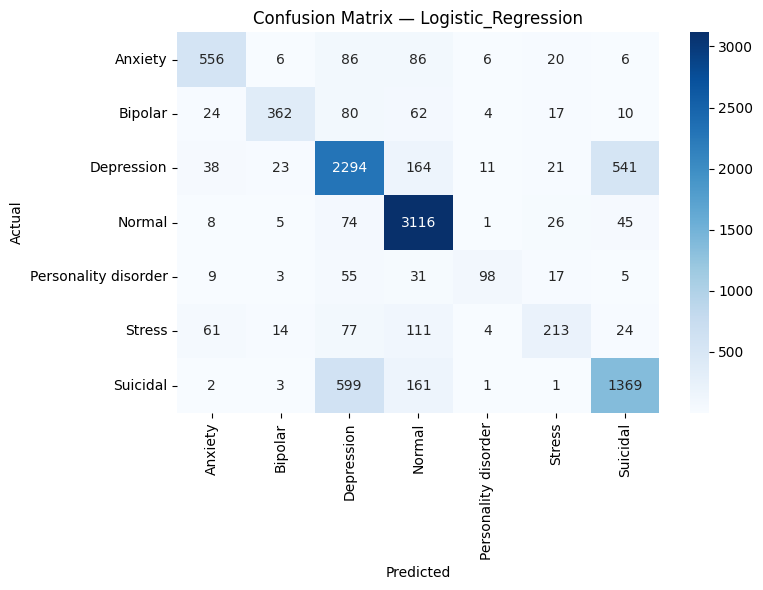

Macro AUC: 0.9543  95% CI [0.9516, 0.9568]
Saved → outputs/01_OriginalLabel/Logistic_Regression_roc_curve.png


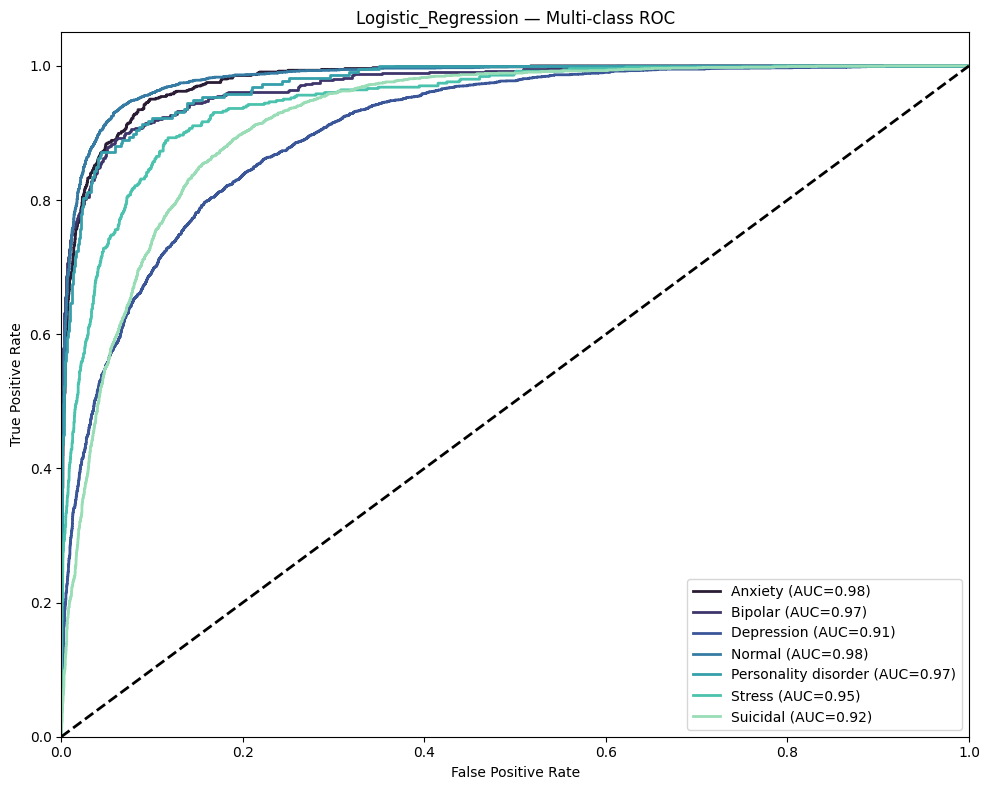

In [21]:
evaluate_ml(best_model_lr, X_test_tfidf, y_test_ml, "Logistic_Regression")

### Step 3: Model Interpretation

Saved → outputs/01_OriginalLabel/logistic_regression_feature_importance.png


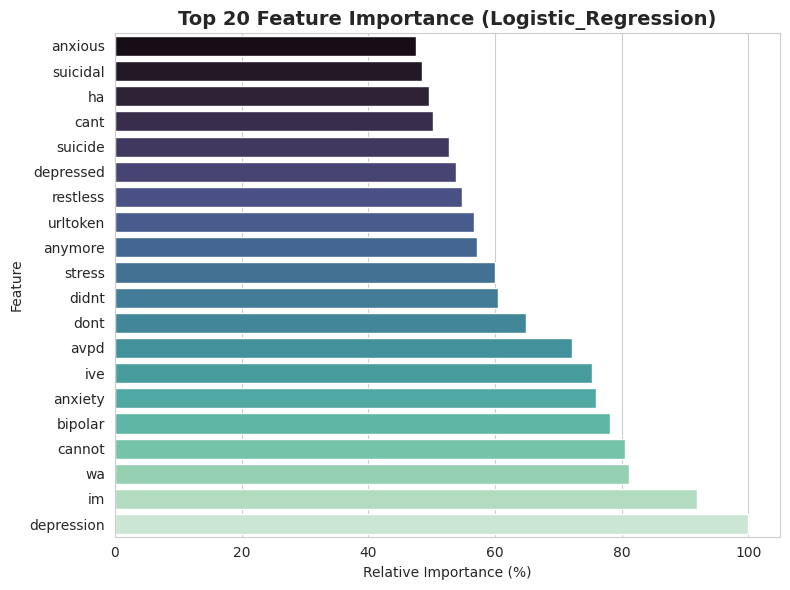

In [22]:
if hasattr(best_model_lr, "coef_"):
    importances_lr = np.abs(best_model_lr.coef_).mean(axis=0) if best_model_lr.coef_.shape[0] > 1 else np.abs(best_model_lr.coef_[0])
    plot_feature_importance(importances_lr, feature_names_tfidf, "Logistic_Regression")

## 3.2 SVM

### Step 1: Hyperparameter Tuning

In [23]:
### Step 1: Hyperparameter Tuning

RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning SVM...")
    start = time.time()

    svm_grid = {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "class_weight": ["balanced", None],
        "gamma": ["scale"],
    }

    best_f1_svm, best_params_svm, best_model_svm = -1.0, None, None

    for C, kernel, class_weight, gamma in product(
        svm_grid["C"], svm_grid["kernel"],
        svm_grid["class_weight"], svm_grid["gamma"]
    ):
        try:
            model = SVC(
                C=C, kernel=kernel, class_weight=class_weight,
                gamma=gamma, random_state=RANDOM_STATE, probability=False,
            )
            model.fit(X_train_tfidf, y_train_ml)
            y_val_pred = model.predict(X_val_tfidf)
            f1 = f1_score(y_val_ml, y_val_pred, average="weighted")

            if f1 > best_f1_svm:
                best_f1_svm = f1
                best_params_svm = {"C": C, "kernel": kernel,
                                   "class_weight": class_weight, "gamma": gamma}
                best_model_svm = model
                print(f"  New best F1: {f1:.4f} | {best_params_svm}")

        except Exception as e:
            print(f"  Skipping: {e}")

    # Retrain best config with probability=True for predict_proba
    print("\nRetraining best SVM with probability=True...")
    best_model_svm = SVC(
        **best_params_svm,
        random_state=RANDOM_STATE, probability=True,
    )
    best_model_svm.fit(X_train_tfidf, y_train_ml)

    elapsed = time.time() - start
    print(f"\nBest SVM: F1={best_f1_svm:.4f} in {elapsed:.1f}s")
    print(f"Params: {best_params_svm}")

    joblib.dump(best_model_svm, MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"], "w") as f:
        json.dump(best_params_svm, f, indent=2)
    print(f"Saved best SVM model to: {MODEL_PATHS['svm']['model']}")
else:
    best_model_svm = joblib.load(MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"]) as f:
        best_params_svm = json.load(f)
    print(f"Loaded saved SVM model. Params: {best_params_svm}")


Tuning SVM...
  New best F1: 0.7195 | {'C': 0.1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
  New best F1: 0.7409 | {'C': 1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
  New best F1: 0.7489 | {'C': 1, 'kernel': 'linear', 'class_weight': None, 'gamma': 'scale'}

Retraining best SVM with probability=True...

Best SVM: F1=0.7489 in 5758.4s
Params: {'C': 1, 'kernel': 'linear', 'class_weight': None, 'gamma': 'scale'}
Saved best SVM model to: outputs/01_OriginalLabel/best_svm_model.joblib


### Step 2: Model Evaluation


Evaluation: SVM
                      precision    recall  f1-score   support

             Anxiety     0.7728    0.7637    0.7682       766
             Bipolar     0.8545    0.6726    0.7528       559
          Depression     0.6956    0.7345    0.7145      3092
              Normal     0.8634    0.9456    0.9027      3275
Personality disorder     0.8145    0.4633    0.5906       218
              Stress     0.6354    0.4563    0.5312       504
            Suicidal     0.6814    0.6428    0.6615      2136

            accuracy                         0.7614     10550
           macro avg     0.7597    0.6684    0.7031     10550
        weighted avg     0.7584    0.7614    0.7568     10550

Weighted F1: 0.7568  95% CI [0.7485, 0.7655]
Macro F1:    0.7031  95% CI [0.6879, 0.7158]
Saved → outputs/01_OriginalLabel/SVM_confusion_matrix.png


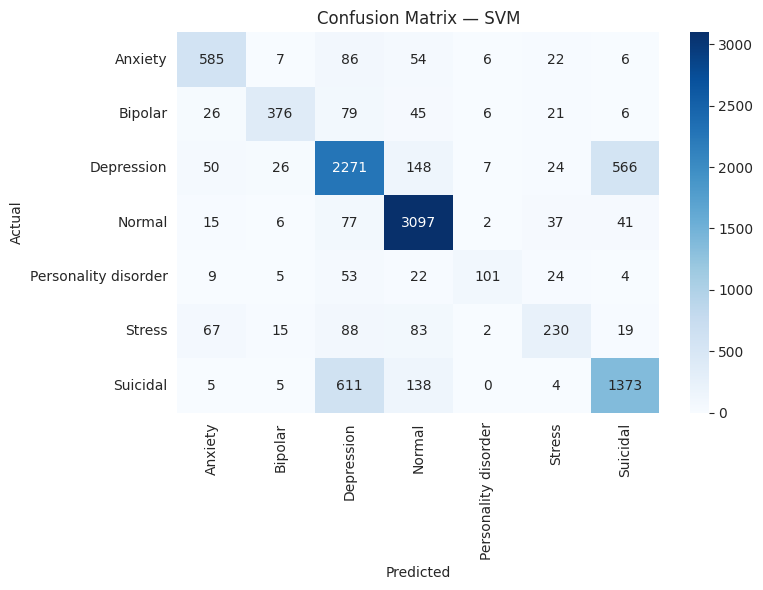

Macro AUC: 0.9534  95% CI [0.9503, 0.9562]
Saved → outputs/01_OriginalLabel/SVM_roc_curve.png


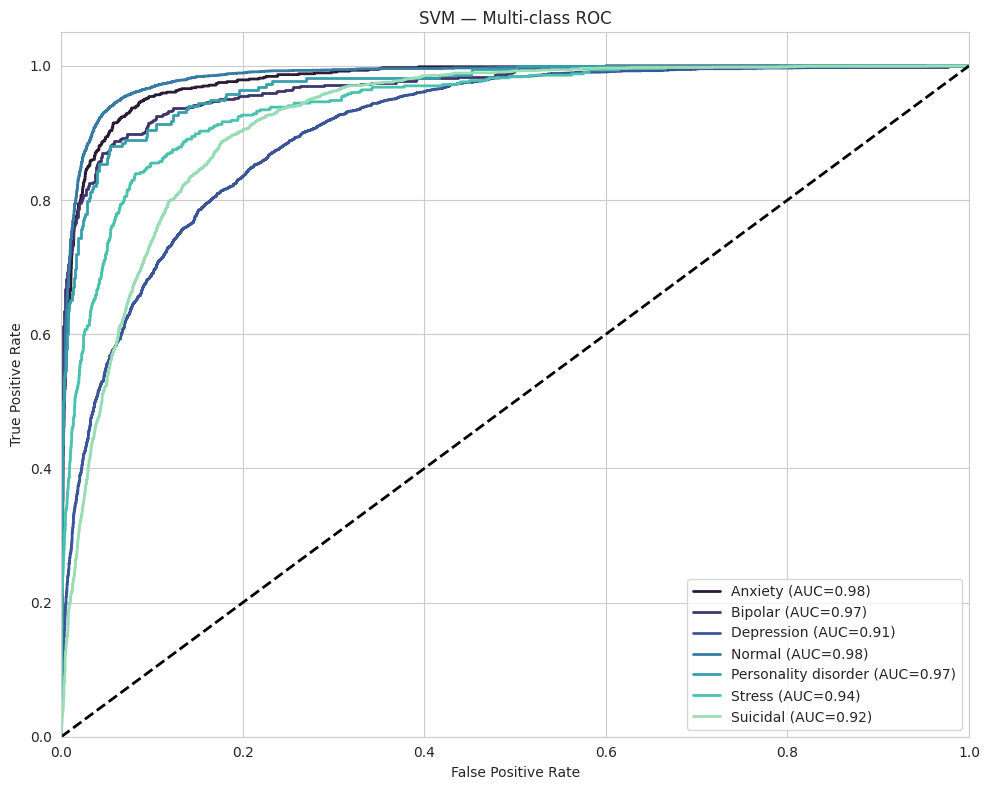

In [24]:
evaluate_ml(best_model_svm, X_test_tfidf, y_test_ml, "SVM")

### Step 3: Model Interpretation

In [25]:
# if best_model_svm.kernel == "linear" and hasattr(best_model_svm, "coef_"):
#     # Linear kernel: use coefficient weights directly (fast)
#     importances_svm = np.abs(best_model_svm.coef_).mean(axis=0)
#     if hasattr(importances_svm, "A1"):  # sparse matrix → flat array
#         importances_svm = importances_svm.A1
#     plot_feature_importance(importances_svm, feature_names_tfidf, "SVM")
# else:
#     # Non-linear kernel: permutation importance (slower)
#     print(f"Kernel='{best_model_svm.kernel}' — using permutation importance...")

#     max_samples = 1000
#     n_val = X_val_tfidf.shape[0]

#     if n_val > max_samples:
#         rng = np.random.RandomState(RANDOM_STATE)
#         idx = rng.choice(n_val, size=max_samples, replace=False)
#         X_perm = X_val_tfidf[idx]
#         y_perm = y_val_ml.iloc[idx] if hasattr(y_val_ml, "iloc") else y_val_ml[idx]
#     else:
#         X_perm = X_val_tfidf
#         y_perm = y_val_ml

#     print(f"Permutation importance on {X_perm.shape[0]} samples...")
#     start = time.time()

#     result = permutation_importance(
#         best_model_svm, X_perm, y_perm,
#         n_repeats=5, random_state=RANDOM_STATE,
#         n_jobs=-1, scoring="f1_weighted",
#     )

#     print(f"Done in {time.time() - start:.1f}s")

#     importances_svm = result.importances_mean.clip(min=0)
#     plot_feature_importance(importances_svm, feature_names_tfidf, "SVM")

## 3.3 Random Forest

### Step 1: Hyperparameter Tuning

In [26]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning Random Forest...")
    start = time.time()

    rf_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": ["balanced", None],
    }

    best_f1_rf, best_model_rf, best_params_rf = 0, None, None

    for n_est, md, mss, msl, cw in tqdm(
        list(product(rf_grid["n_estimators"], rf_grid["max_depth"],
                     rf_grid["min_samples_split"], rf_grid["min_samples_leaf"],
                     rf_grid["class_weight"])),
        desc="RF grid"
    ):
        try:
            model = RandomForestClassifier(
                n_estimators=n_est, max_depth=md, min_samples_split=mss,
                min_samples_leaf=msl, class_weight=cw,
                random_state=RANDOM_STATE, n_jobs=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_rf:
                best_f1_rf = f1
                best_model_rf = model
                best_params_rf = {"n_estimators": n_est, "max_depth": md,
                                  "min_samples_split": mss, "min_samples_leaf": msl,
                                  "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"RF tuning: {time.time()-start:.1f}s | Best F1={best_f1_rf:.4f}")
    print(f"Best params: {best_params_rf}")

    joblib.dump(best_model_rf, MODEL_PATHS["rf"]["model"])
    with open(MODEL_PATHS["rf"]["params"], "w") as f:
        json.dump(best_params_rf, f, indent=2)
else:
    print("Loading RF from disk...")
    best_model_rf = joblib.load(MODEL_PATHS["rf"]["model"])
    print(f"Loaded RF from {MODEL_PATHS['rf']['model']}")


Tuning Random Forest...


RF grid: 100%|██████████| 162/162 [08:20<00:00,  3.09s/it]


RF tuning: 500.7s | Best F1=0.7292
Best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 4, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: RandomForest
                      precision    recall  f1-score   support

             Anxiety     0.6976    0.8251    0.7560       766
             Bipolar     0.7213    0.7406    0.7308       559
          Depression     0.7663    0.6151    0.6825      3092
              Normal     0.8732    0.9148    0.8935      3275
Personality disorder     0.7532    0.5459    0.6330       218
              Stress     0.4982    0.5536    0.5244       504
            Suicidal     0.6228    0.7111    0.6640      2136

            accuracy                         0.7451     10550
           macro avg     0.7046    0.7009    0.6977     10550
        weighted avg     0.7500    0.7451    0.7436     10550

Weighted F1: 0.7436  95% CI [0.7351, 0.7519]
Macro F1:    0.6977  95% CI [0.6832, 0.7099]
Saved → outputs/01_OriginalLabel/RandomForest_confusion_matrix.png


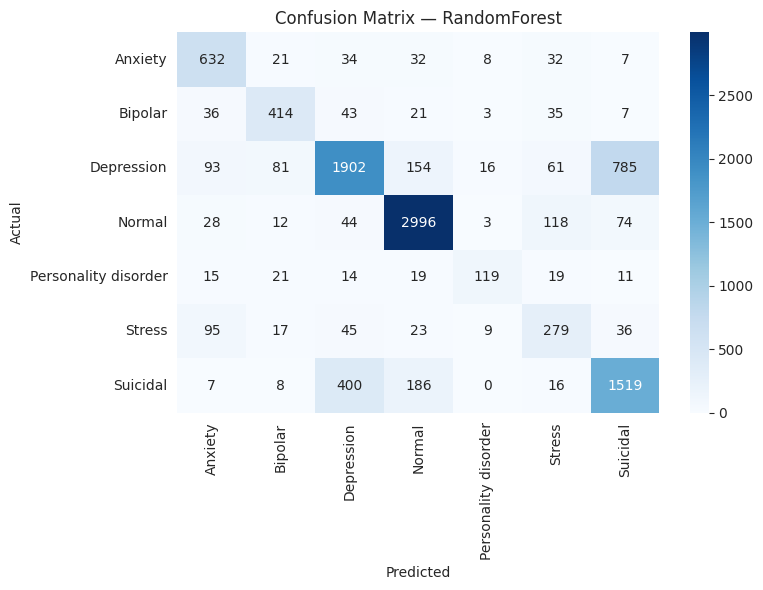

Macro AUC: 0.9334  95% CI [0.9299, 0.9370]
Saved → outputs/01_OriginalLabel/RandomForest_roc_curve.png


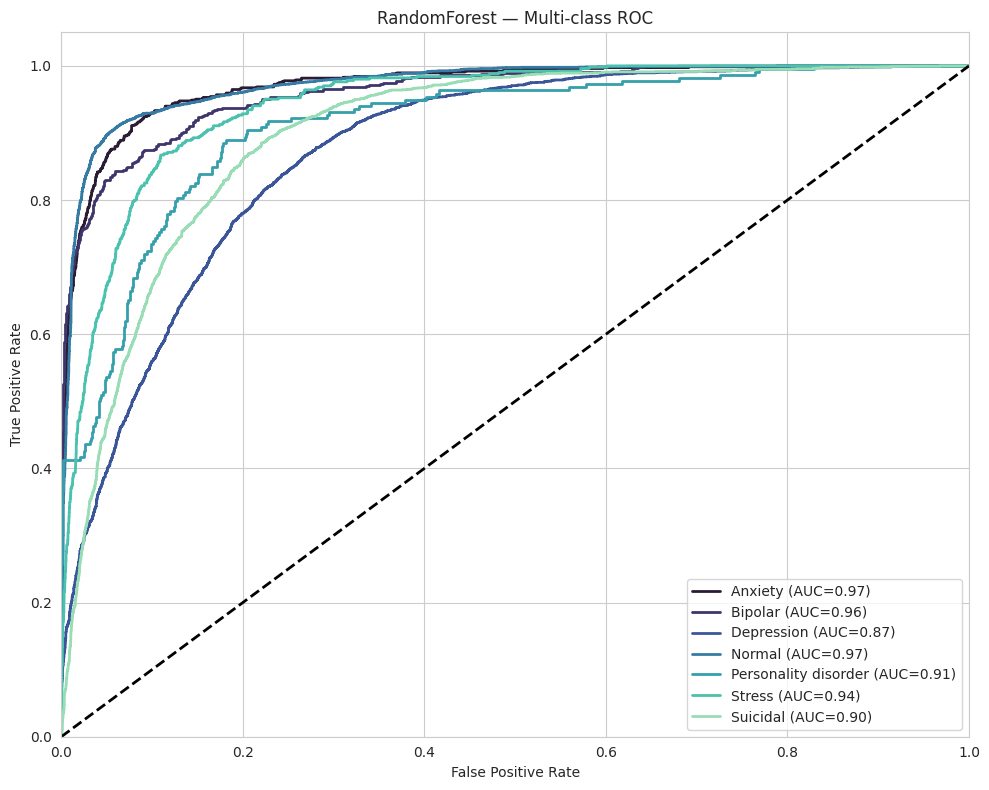

In [27]:
evaluate_ml(best_model_rf, X_test_tfidf, y_test_ml, "RandomForest")

### Step 3: Model Interpretation

Saved → outputs/01_OriginalLabel/randomforest_feature_importance.png


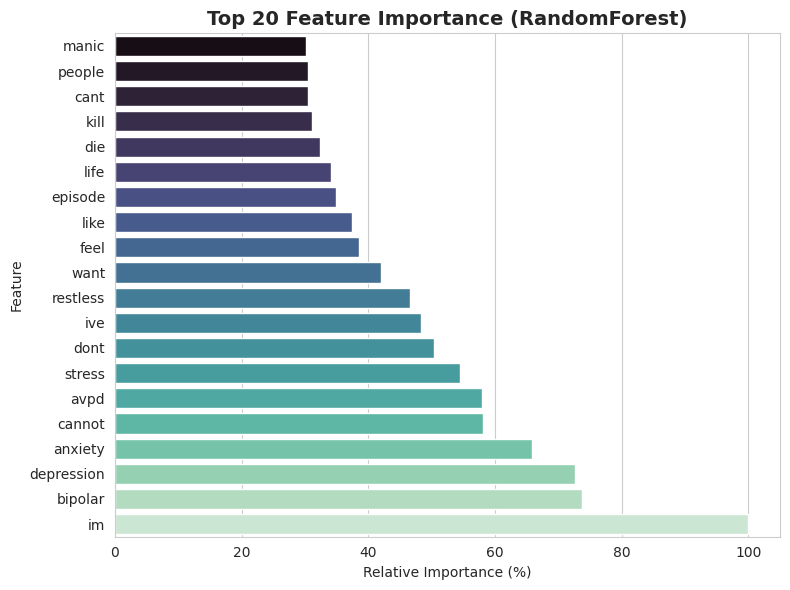

,Feature,Importance,Scaled
4512,im,0.027837,100.000000
1120,bipolar,0.020506,73.665295
2451,depression,0.020232,72.679302
630,anxiety,0.018308,65.769288
1455,cannot,0.016157,58.041543
876,avpd,0.016154,58.032578
8491,stress,0.015168,54.488325
2765,dont,0.014014,50.342252
4887,ive,0.013441,48.285535
7426,restless,0.012963,46.568769


In [28]:
plot_feature_importance(best_model_rf.feature_importances_, feature_names_tfidf, "RandomForest")

## 3.4 LGBM

### Step 1: Hyperparameter Tuning

In [29]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning LightGBM...")
    start = time.time()

    lgbm_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "num_leaves": [31, 63],
        "max_depth": [None, 10],
        "class_weight": ["balanced", None],
    }

    best_f1_lgbm, best_model_lgbm, best_params_lgbm = 0, None, None

    for n_est, lr, nl, md, cw in tqdm(
        list(product(lgbm_grid["n_estimators"], lgbm_grid["learning_rate"],
                     lgbm_grid["num_leaves"], lgbm_grid["max_depth"],
                     lgbm_grid["class_weight"])),
        desc="LGBM grid"
    ):
        try:
            model = LGBMClassifier(
                objective="multiclass", n_estimators=n_est, learning_rate=lr,
                num_leaves=nl, max_depth=-1 if md is None else md,
                class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1,
                verbose=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lgbm:
                best_f1_lgbm = f1
                best_model_lgbm = model
                best_params_lgbm = {"n_estimators": n_est, "learning_rate": lr,
                                    "num_leaves": nl, "max_depth": md, "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LGBM tuning: {time.time()-start:.1f}s | Best F1={best_f1_lgbm:.4f}")
    print(f"Best params: {best_params_lgbm}")

    joblib.dump(best_model_lgbm, MODEL_PATHS["lgbm"]["model"])
    with open(MODEL_PATHS["lgbm"]["params"], "w") as f:
        json.dump(best_params_lgbm, f, indent=2)
else:
    print("Loading LGBM from disk...")
    best_model_lgbm = joblib.load(MODEL_PATHS["lgbm"]["model"])
    print(f"Loaded LGBM from {MODEL_PATHS['lgbm']['model']}")



Tuning LightGBM...


LGBM grid: 100%|██████████| 48/48 [36:08<00:00, 45.17s/it]

LGBM tuning: 2168.2s | Best F1=0.7654
Best params: {'n_estimators': 200, 'learning_rate': 0.1, 'num_leaves': 31, 'max_depth': None, 'class_weight': None}


### Step 2: Model Evaluation


Evaluation: LightGBM
                      precision    recall  f1-score   support

             Anxiety     0.7875    0.7742    0.7808       766
             Bipolar     0.8820    0.7084    0.7857       559
          Depression     0.7171    0.7435    0.7301      3092
              Normal     0.8750    0.9429    0.9077      3275
Personality disorder     0.7967    0.4495    0.5748       218
              Stress     0.6322    0.4980    0.5572       504
            Suicidal     0.6832    0.6695    0.6763      2136

            accuracy                         0.7730     10550
           macro avg     0.7677    0.6837    0.7161     10550
        weighted avg     0.7707    0.7730    0.7695     10550

Weighted F1: 0.7695  95% CI [0.7610, 0.7776]
Macro F1:    0.7161  95% CI [0.7019, 0.7294]
Saved → outputs/01_OriginalLabel/LightGBM_confusion_matrix.png


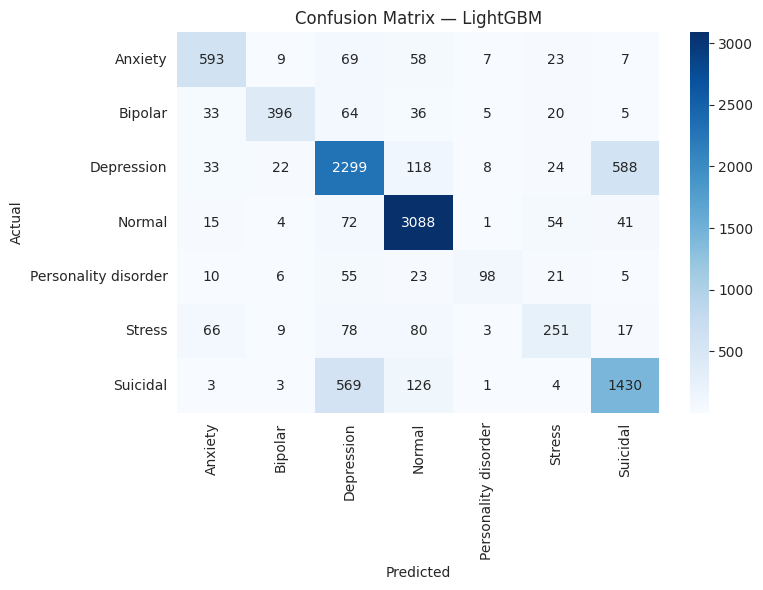

Macro AUC: 0.9451  95% CI [0.9412, 0.9490]
Saved → outputs/01_OriginalLabel/LightGBM_roc_curve.png


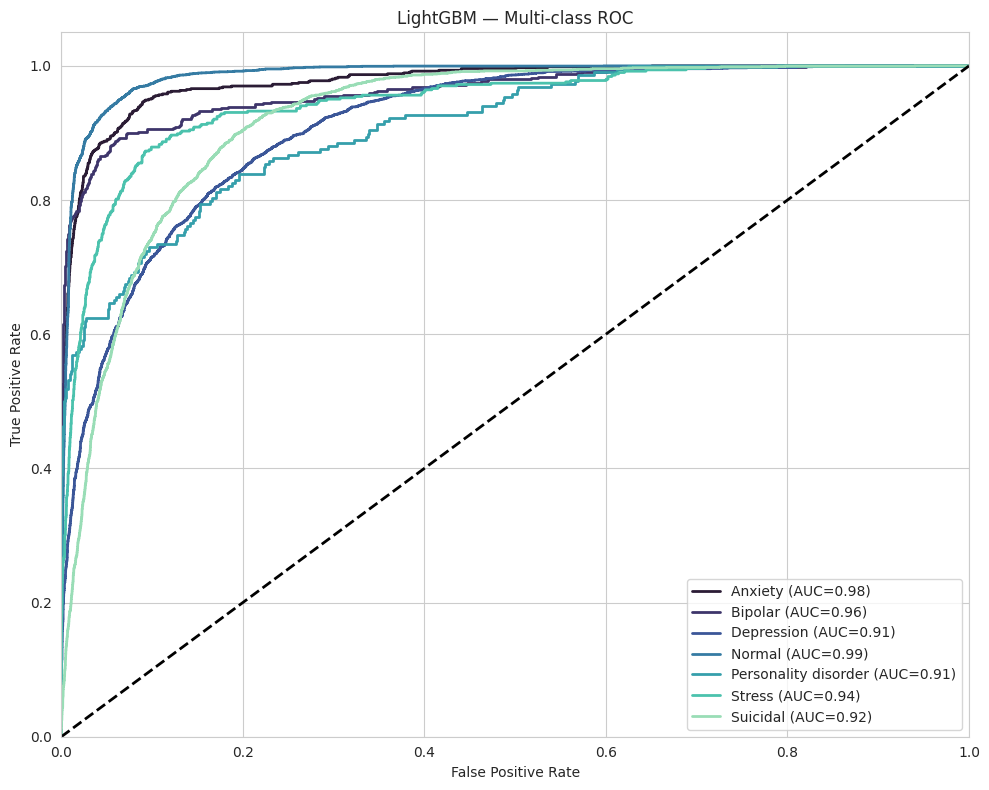

In [30]:
evaluate_ml(best_model_lgbm, X_test_tfidf, y_test_ml, "LightGBM")

### Step 3: Model Interpretation

Saved → outputs/01_OriginalLabel/lightgbm_feature_importance.png


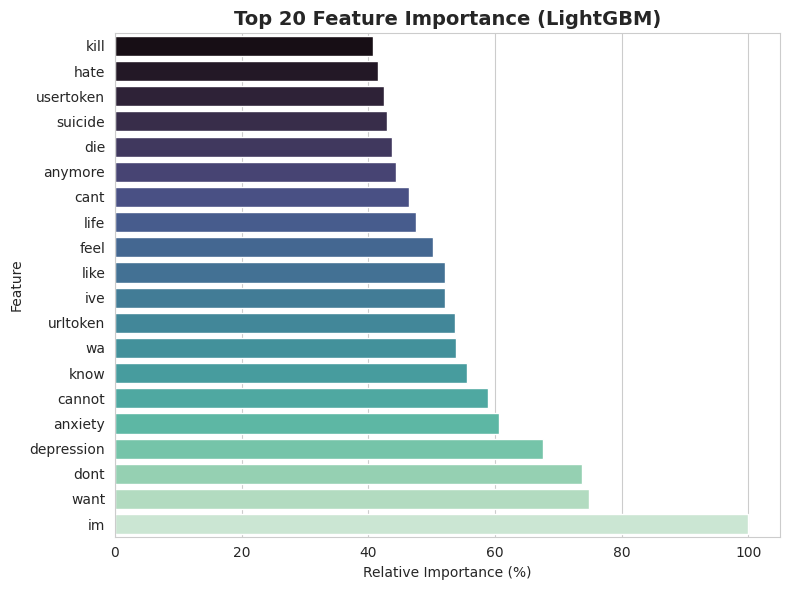

,Feature,Importance,Scaled
4512,im,414,100.000000
9651,want,310,74.879227
2765,dont,305,73.671498
2451,depression,280,67.632850
630,anxiety,251,60.628019
1455,cannot,244,58.937198
5033,know,230,55.555556
9621,wa,223,53.864734
9453,urltoken,222,53.623188
4887,ive,216,52.173913


In [31]:
plot_feature_importance(best_model_lgbm.feature_importances_, feature_names_tfidf, "LightGBM")

## 3.4 Save Predictions for Machine Learning Models

In [32]:
print("\nSaving ML predictions...")

y_true_str = df_test_ml[LABEL_COLUMN].astype(str).values
y_true_id  = label_encoder.transform(y_true_str)

lr_pred   = best_model_lr.predict(X_test_tfidf)
svm_pred  = best_model_svm.predict(X_test_tfidf)
rf_pred   = best_model_rf.predict(X_test_tfidf)
lgbm_pred = best_model_lgbm.predict(X_test_tfidf)

lr_proba   = best_model_lr.predict_proba(X_test_tfidf)
svm_proba  = best_model_svm.predict_proba(X_test_tfidf)
rf_proba   = best_model_rf.predict_proba(X_test_tfidf)
lgbm_proba = best_model_lgbm.predict_proba(X_test_tfidf)

class_names_ml = best_model_lr.classes_
assert np.array_equal(class_names_ml, best_model_svm.classes_)
assert np.array_equal(class_names_ml, best_model_rf.classes_)
assert np.array_equal(class_names_ml, best_model_lgbm.classes_)

# Build prediction DataFrame
if "id" in df_test_ml.columns:
    df_pred_ml = df_test_ml[["id", TEXT_COLUMN]].copy()
else:
    df_pred_ml = df_test_ml[[TEXT_COLUMN]].copy()
    df_pred_ml.insert(0, "id", df_test_ml.index)

df_pred_ml["true_label"]    = y_true_str
df_pred_ml["true_label_id"] = y_true_id
df_pred_ml["lr_pred"]       = lr_pred
df_pred_ml["svm_pred"]      = svm_pred
df_pred_ml["rf_pred"]       = rf_pred
df_pred_ml["lgbm_pred"]     = lgbm_pred

for i, cls in enumerate(class_names_ml):
    df_pred_ml[f"lr_prob_{cls}"]   = lr_proba[:, i]
    df_pred_ml[f"svm_prob_{cls}"]  = svm_proba[:, i]
    df_pred_ml[f"rf_prob_{cls}"]   = rf_proba[:, i]
    df_pred_ml[f"lgbm_prob_{cls}"] = lgbm_proba[:, i]

ml_pred_path = OUTPUT_PATH / "ml_models_predictions.csv"
df_pred_ml.to_csv(ml_pred_path, index=False)
print(f"Saved ML predictions → {ml_pred_path}")


Saving ML predictions...
Saved ML predictions → outputs/01_OriginalLabel/ml_models_predictions.csv


# 4. DL Models


## 4.0 Pre-processing \& data preparation for DL Models

In [ ]:
df_train_dl = df_clean[df_clean["split"] == "train"].copy()
df_val_dl   = df_clean[df_clean["split"] == "val"].copy()
df_test_dl  = df_clean[df_clean["split"] == "test"].copy()

train_labels_dl = df_train_dl[LABEL_COLUMN_ENCODED].tolist()
val_labels_dl   = df_val_dl[LABEL_COLUMN_ENCODED].tolist()
test_labels_dl  = df_test_dl[LABEL_COLUMN_ENCODED].tolist()

# ── GRU/CNN and Transformers all use augmented text (model_text) ──
train_texts_dl = df_train_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
val_texts_dl   = df_val_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
test_texts_dl  = df_test_dl[TEXT_COLUMN].fillna("").astype(str).tolist()

print(f"DL splits: train={len(train_texts_dl)}, val={len(val_texts_dl)}, test={len(test_texts_dl)}")

# ── Build shared vocabulary (GRU + CNN — from raw text) ──
# PAD=0, UNK=1, words start at 2
vocab_counter = Counter()
for text in train_texts_dl:
    vocab_counter.update(text.split())
most_common = [w for w, _ in vocab_counter.most_common(VOCAB_SIZE - 2)]  # -2 for PAD and UNK
word_to_index = {w: i + 2 for i, w in enumerate(most_common)}  # 0=PAD, 1=UNK
UNK_IDX = 1

print(f"Vocabulary: {len(word_to_index)} words + PAD(0) + UNK(1)")


def text_to_sequence(text, w2i, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    return [w2i.get(w, UNK_IDX) for w in tokens][:max_len]


# ── Convert & pad sequences (fixed length = MAX_TOKEN_LENGTH) ──
def build_padded_sequences(texts, w2i, max_len=MAX_TOKEN_LENGTH):
    seqs = []
    for t in texts:
        seq = text_to_sequence(t, w2i, max_len)
        # Pad to exactly max_len (not max-in-split)
        padded = seq + [0] * (max_len - len(seq))
        seqs.append(padded)
    return torch.tensor(seqs, dtype=torch.long)

train_seqs = build_padded_sequences(train_texts_dl, word_to_index)
val_seqs   = build_padded_sequences(val_texts_dl, word_to_index)
test_seqs  = build_padded_sequences(test_texts_dl, word_to_index)

train_labels_t = torch.tensor(train_labels_dl, dtype=torch.long)
val_labels_t   = torch.tensor(val_labels_dl, dtype=torch.long)
test_labels_t  = torch.tensor(test_labels_dl, dtype=torch.long)

print(f"Sequence shapes: train={train_seqs.shape}, val={val_seqs.shape}, test={test_seqs.shape}")

DL splits: train=31976, val=10517, test=10550
Vocabulary: 9998 words + PAD(0) + UNK(1)
Sequence shapes: train=torch.Size([31976, 200]), val=torch.Size([10517, 200]), test=torch.Size([10550, 200])


In [ ]:
# ── Dataset class (GRU + CNN) ────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"input_ids": self.sequences[idx], "label": self.labels[idx]}


# ── DataLoaders (shared, with pin_memory) ────────────────
_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                  pin_memory=True, persistent_workers=True)

train_loader_seq = DataLoader(SeqDataset(train_seqs, train_labels_t), shuffle=True, **_loader_kw)
val_loader_seq   = DataLoader(SeqDataset(val_seqs, val_labels_t), shuffle=False, **_loader_kw)
test_loader_seq  = DataLoader(SeqDataset(test_seqs, test_labels_t), shuffle=False, **_loader_kw)

# ── Class weights for DL training ────────────────────────
_cw = compute_class_weight("balanced", classes=np.unique(train_labels_dl), y=train_labels_dl)
class_weights_dl = torch.tensor(_cw, dtype=torch.float32).to(DEVICE)

## 4.1 Neural Network (GRU \& CNN)

### 4.1.1 Generic train + evaluation

In [ ]:
def train_seq_model(model, train_loader, val_loader, lr=1e-3,
                    max_epochs=20, patience=5):
    """Train a sequence model (GRU or CNN) with early stopping."""
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                logits = model(ids)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), SEQ_MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE, non_blocking=True)
                labels = batch["label"]
                with autocast("cuda", enabled=USE_FP16):
                    logits = model(ids)
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(labels.numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        val_acc = accuracy_score(val_true, val_preds)
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | "
              f"Val F1={val_f1:.4f} | Val Acc={val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model

### 4.1.2 GRU

#### Step 1: Define GRU Model

In [ ]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)
        return self.fc(self.dropout(hidden[-1]))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning GRU...")
    start = time.time()

    MAX_EPOCHS_GRU = 20
    PATIENCE_GRU = 5

    gru_param_space = {
        "embedding_dim": (150, 300),
        "hidden_dim": (128, 384),
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_gru, best_params_gru, best_gru = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="GRU Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*gru_param_space["embedding_dim"])),
            "hidden_dim": int(np.random.uniform(*gru_param_space["hidden_dim"])),
            "lr": float(10 ** np.random.uniform(*gru_param_space["lr"])),
        }

        model = GRUSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            hidden_dim=hp["hidden_dim"], output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_GRU, patience=PATIENCE_GRU,
        )

        if f1_val > best_f1_gru:
            best_f1_gru = f1_val
            best_params_gru = hp
            best_gru = model

    print(f"GRU tuning: {time.time()-start:.1f}s | Best F1={best_f1_gru:.4f}")
    print(f"Best params: {best_params_gru}")

    torch.save(best_gru.state_dict(), MODEL_PATHS["gru"]["model"])
    with open(MODEL_PATHS["gru"]["params"], "w") as f:
        json.dump(best_params_gru, f, indent=2)
else:
    print("Loading GRU from disk...")
    with open(MODEL_PATHS["gru"]["params"]) as f:
        best_params_gru = json.load(f)
    best_gru = GRUSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_gru["embedding_dim"]),
        hidden_dim=int(best_params_gru["hidden_dim"]), output_dim=NUM_CLASSES,
    )
    best_gru.load_state_dict(torch.load(MODEL_PATHS["gru"]["model"], map_location=DEVICE))
    print(f"Loaded GRU from {MODEL_PATHS['gru']['model']}")



Tuning GRU...


GRU Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.9112 | Val F1=0.2721 | Val Acc=0.3808
  Epoch 2/20 | Loss=1.5386 | Val F1=0.5693 | Val Acc=0.5735
  Epoch 3/20 | Loss=1.1037 | Val F1=0.6716 | Val Acc=0.6740
  Epoch 4/20 | Loss=0.7230 | Val F1=0.7061 | Val Acc=0.6871
  Epoch 5/20 | Loss=0.5452 | Val F1=0.7367 | Val Acc=0.7267
  Epoch 6/20 | Loss=0.4166 | Val F1=0.7292 | Val Acc=0.7189
  Epoch 7/20 | Loss=0.3525 | Val F1=0.7482 | Val Acc=0.7455
  Epoch 8/20 | Loss=0.2826 | Val F1=0.7451 | Val Acc=0.7452
  Epoch 9/20 | Loss=0.2488 | Val F1=0.7444 | Val Acc=0.7412
  Epoch 10/20 | Loss=0.2136 | Val F1=0.7447 | Val Acc=0.7445
  Epoch 11/20 | Loss=0.1895 | Val F1=0.7394 | Val Acc=0.7363


GRU Random Search:  10%|█         | 1/10 [00:38<05:50, 38.90s/it]

  Epoch 12/20 | Loss=0.1662 | Val F1=0.7391 | Val Acc=0.7364
  Early stopping at epoch 12.
  Epoch 1/20 | Loss=1.9218 | Val F1=0.2491 | Val Acc=0.3582
  Epoch 2/20 | Loss=1.8345 | Val F1=0.3251 | Val Acc=0.3603
  Epoch 3/20 | Loss=1.7173 | Val F1=0.4194 | Val Acc=0.4553
  Epoch 4/20 | Loss=1.5911 | Val F1=0.5037 | Val Acc=0.5290
  Epoch 5/20 | Loss=1.3964 | Val F1=0.5024 | Val Acc=0.5230
  Epoch 6/20 | Loss=1.3178 | Val F1=0.5301 | Val Acc=0.5481
  Epoch 7/20 | Loss=1.2689 | Val F1=0.5371 | Val Acc=0.5600
  Epoch 8/20 | Loss=1.2174 | Val F1=0.6068 | Val Acc=0.5974
  Epoch 9/20 | Loss=1.1449 | Val F1=0.6109 | Val Acc=0.6122
  Epoch 10/20 | Loss=1.0608 | Val F1=0.5948 | Val Acc=0.6115
  Epoch 11/20 | Loss=0.9569 | Val F1=0.6437 | Val Acc=0.6462
  Epoch 12/20 | Loss=0.8626 | Val F1=0.6581 | Val Acc=0.6566
  Epoch 13/20 | Loss=0.7994 | Val F1=0.6567 | Val Acc=0.6600
  Epoch 14/20 | Loss=0.7558 | Val F1=0.6605 | Val Acc=0.6612
  Epoch 15/20 | Loss=0.7053 | Val F1=0.6697 | Val Acc=0.6687
  E

...

  Epoch 20/20 | Loss=0.6024 | Val F1=0.6930 | Val Acc=0.6890
  Epoch 1/20 | Loss=1.9088 | Val F1=0.2740 | Val Acc=0.3763
  Epoch 2/20 | Loss=1.8192 | Val F1=0.4421 | Val Acc=0.4905
  Epoch 3/20 | Loss=1.5540 | Val F1=0.4612 | Val Acc=0.5135
  Epoch 4/20 | Loss=1.3552 | Val F1=0.5641 | Val Acc=0.5625
  Epoch 5/20 | Loss=1.2763 | Val F1=0.5924 | Val Acc=0.5812
  Epoch 6/20 | Loss=1.1429 | Val F1=0.6246 | Val Acc=0.6044
  Epoch 7/20 | Loss=0.9440 | Val F1=0.6660 | Val Acc=0.6478
  Epoch 8/20 | Loss=0.8243 | Val F1=0.6759 | Val Acc=0.6660
  Epoch 9/20 | Loss=0.7319 | Val F1=0.6810 | Val Acc=0.6806
  Epoch 10/20 | Loss=0.6826 | Val F1=0.6994 | Val Acc=0.6968
  Epoch 11/20 | Loss=0.6182 | Val F1=0.7011 | Val Acc=0.7000
  Epoch 12/20 | Loss=0.5734 | Val F1=0.6895 | Val Acc=0.6940
  Epoch 13/20 | Loss=0.5413 | Val F1=0.7249 | Val Acc=0.7240
  Epoch 14/20 | Loss=0.5143 | Val F1=0.7276 | Val Acc=0.7243
  Epoch 15/20 | Loss=0.4818 | Val F1=0.7307 | Val Acc=0.7288
  Epoch 16/20 | Loss=0.4672 | Val

GRU Random Search:  90%|█████████ | 9/10 [07:24<00:54, 54.94s/it]

  Epoch 20/20 | Loss=0.4044 | Val F1=0.7360 | Val Acc=0.7345
  Epoch 1/20 | Loss=1.9353 | Val F1=0.2497 | Val Acc=0.3607
  Epoch 2/20 | Loss=1.8998 | Val F1=0.2656 | Val Acc=0.3706
  Epoch 3/20 | Loss=1.8437 | Val F1=0.3965 | Val Acc=0.4694
  Epoch 4/20 | Loss=1.7596 | Val F1=0.4373 | Val Acc=0.4811
  Epoch 5/20 | Loss=1.7192 | Val F1=0.4086 | Val Acc=0.4610
  Epoch 6/20 | Loss=1.6820 | Val F1=0.4311 | Val Acc=0.4725
  Epoch 7/20 | Loss=1.6254 | Val F1=0.4495 | Val Acc=0.4963
  Epoch 8/20 | Loss=1.5216 | Val F1=0.4778 | Val Acc=0.5196
  Epoch 9/20 | Loss=1.4282 | Val F1=0.5001 | Val Acc=0.5218
  Epoch 10/20 | Loss=1.3733 | Val F1=0.5238 | Val Acc=0.5171
  Epoch 11/20 | Loss=1.3211 | Val F1=0.5287 | Val Acc=0.5353
  Epoch 12/20 | Loss=1.2883 | Val F1=0.5283 | Val Acc=0.5434
  Epoch 13/20 | Loss=1.2589 | Val F1=0.5332 | Val Acc=0.5438
  Epoch 14/20 | Loss=1.2367 | Val F1=0.5315 | Val Acc=0.5183
  Epoch 15/20 | Loss=1.2109 | Val F1=0.5618 | Val Acc=0.5613
  Epoch 16/20 | Loss=1.1831 | Val

GRU Random Search: 100%|██████████| 10/10 [08:36<00:00, 51.63s/it]

  Epoch 20/20 | Loss=1.0891 | Val F1=0.5544 | Val Acc=0.5729
GRU tuning: 516.3s | Best F1=0.7552
Best params: {'embedding_dim': 248, 'hidden_dim': 254, 'lr': 0.0009209550194493248}


#### Step 3: Model Evaluation

Eval GRU: 100%|██████████| 83/83 [00:00<00:00, 191.98it/s]



Evaluation: GRU
                      precision    recall  f1-score   support

             Anxiety     0.7358    0.7781    0.7563       766
              Normal     0.9203    0.9029    0.9115      3275
          Depression     0.7707    0.6381    0.6982      3092
            Suicidal     0.6328    0.7795    0.6986      2136
              Stress     0.4711    0.6151    0.5336       504
             Bipolar     0.7925    0.6834    0.7339       559
Personality disorder     0.5306    0.4771    0.5024       218

            accuracy                         0.7571     10550
           macro avg     0.6934    0.6963    0.6906     10550
        weighted avg     0.7686    0.7571    0.7587     10550

Weighted F1: 0.7587  95% CI [0.7499, 0.7665]
Macro F1:    0.6906  95% CI [0.6766, 0.7032]
Saved → outputs/01_OriginalLabel/GRU_confusion_matrix.png


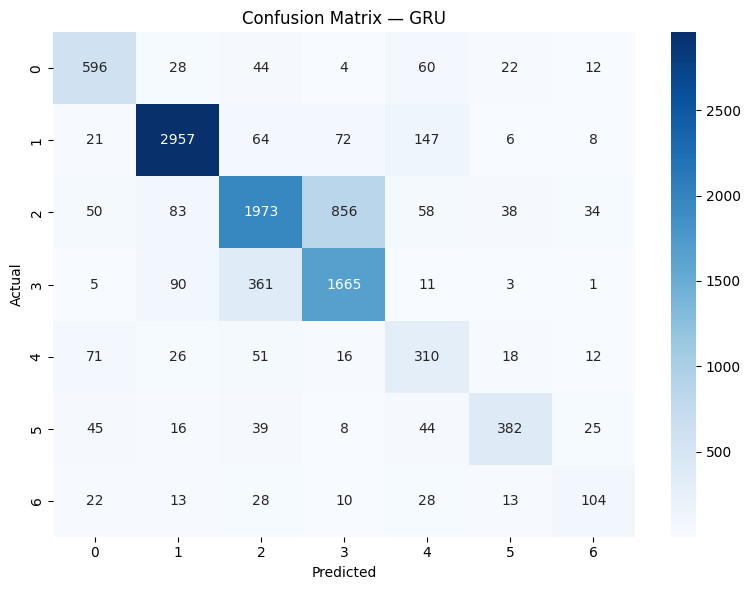

Macro AUC: 0.9450  95% CI [0.9411, 0.9487]
Saved → outputs/01_OriginalLabel/GRU_roc_curve.png


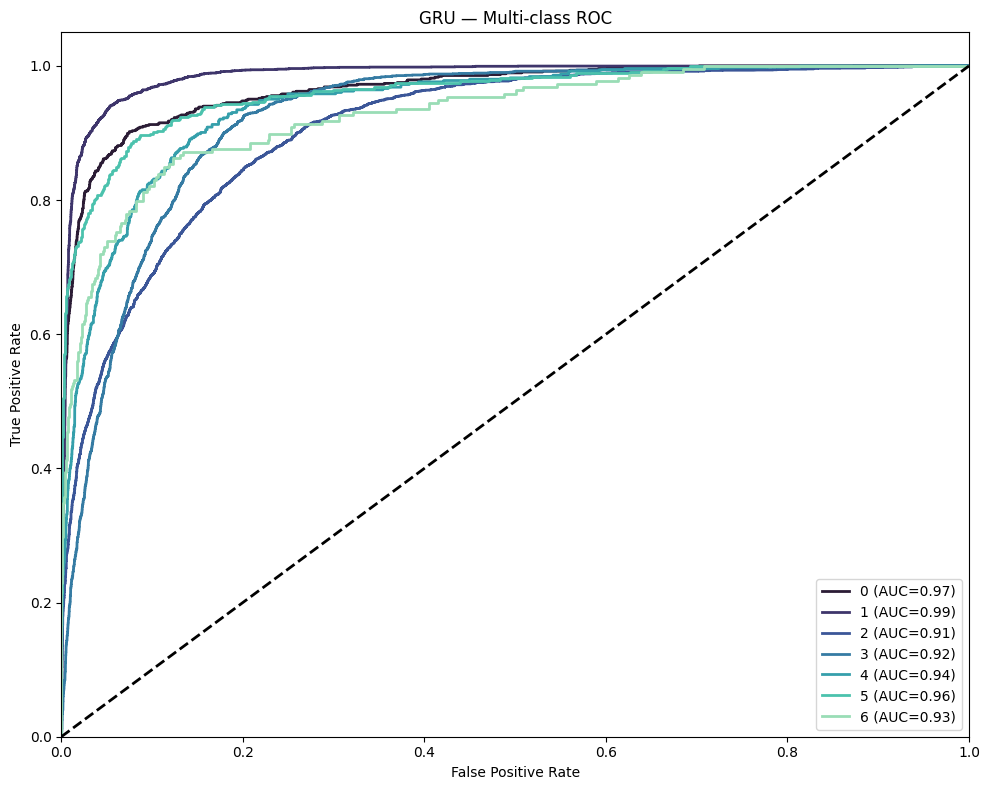

In [ ]:
gru_preds, gru_probs, y_true_gru = evaluate_pytorch(
    best_gru, test_loader_seq, label_encoder, "GRU", use_attention_mask=False
)

### 4.1.3 CNN

### 4.2.2 CNN Modeling

#### Step 1: Define CNN Model

In [ ]:
class CNNSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes,
                 output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.fc = nn.Linear(num_filters * len(filter_sizes), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        x = self.embedding(input_ids).permute(0, 2, 1)  # [B, E, L]
        pooled = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        cat = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(cat))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

FILTER_SIZES = [3, 4, 5]

if RETRAIN:
    set_seed()
    print("\nTuning CNN...")
    start = time.time()

    MAX_EPOCHS_CNN = 20
    PATIENCE_CNN = 5

    cnn_param_space = {
        "embedding_dim": (150, 300),     # uniform
        "num_filters":  (80, 200),       # filters per kernel size
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_cnn, best_params_cnn, best_cnn = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="CNN Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*cnn_param_space["embedding_dim"])),
            "num_filters": int(np.random.uniform(*cnn_param_space["num_filters"])),
            "lr": float(10 ** np.random.uniform(*cnn_param_space["lr"])),
        }

        model = CNNSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            num_filters=hp["num_filters"], filter_sizes=FILTER_SIZES,
            output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_CNN, patience=PATIENCE_CNN,
        )

        if f1_val > best_f1_cnn:
            best_f1_cnn = f1_val
            best_params_cnn = hp
            best_cnn = model

    print(f"CNN tuning: {time.time()-start:.1f}s | Best F1={best_f1_cnn:.4f}")
    print(f"Best params: {best_params_cnn}")

    torch.save(best_cnn.state_dict(), MODEL_PATHS["cnn"]["model"])
    with open(MODEL_PATHS["cnn"]["params"], "w") as f:
        json.dump(best_params_cnn, f, indent=2)
else:
    print("Loading CNN from disk...")
    with open(MODEL_PATHS["cnn"]["params"]) as f:
        best_params_cnn = json.load(f)
    best_cnn = CNNSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_cnn["embedding_dim"]),
        num_filters=int(best_params_cnn["num_filters"]), filter_sizes=FILTER_SIZES,
        output_dim=NUM_CLASSES,
    )
    best_cnn.load_state_dict(torch.load(MODEL_PATHS["cnn"]["model"], map_location=DEVICE))
    print(f"Loaded CNN from {MODEL_PATHS['cnn']['model']}")


Tuning CNN...


CNN Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.3612 | Val F1=0.7018 | Val Acc=0.6903
  Epoch 2/20 | Loss=0.8742 | Val F1=0.6888 | Val Acc=0.6988
  Epoch 3/20 | Loss=0.6911 | Val F1=0.7386 | Val Acc=0.7334
  Epoch 4/20 | Loss=0.5737 | Val F1=0.7316 | Val Acc=0.7319
  Epoch 5/20 | Loss=0.4840 | Val F1=0.7535 | Val Acc=0.7481
  Epoch 6/20 | Loss=0.4163 | Val F1=0.7500 | Val Acc=0.7495
  Epoch 7/20 | Loss=0.3637 | Val F1=0.7564 | Val Acc=0.7562
  Epoch 8/20 | Loss=0.3195 | Val F1=0.7210 | Val Acc=0.7276
  Epoch 9/20 | Loss=0.2930 | Val F1=0.7541 | Val Acc=0.7545
  Epoch 10/20 | Loss=0.2570 | Val F1=0.7604 | Val Acc=0.7614
  Epoch 11/20 | Loss=0.2331 | Val F1=0.7535 | Val Acc=0.7550
  Epoch 12/20 | Loss=0.2171 | Val F1=0.7402 | Val Acc=0.7424
  Epoch 13/20 | Loss=0.1987 | Val F1=0.7457 | Val Acc=0.7461
  Epoch 14/20 | Loss=0.1758 | Val F1=0.7499 | Val Acc=0.7512


CNN Random Search:  10%|█         | 1/10 [00:22<03:22, 22.50s/it]

  Epoch 15/20 | Loss=0.1606 | Val F1=0.7496 | Val Acc=0.7503
  Early stopping at epoch 15.
  Epoch 1/20 | Loss=1.7054 | Val F1=0.6012 | Val Acc=0.5961
  Epoch 2/20 | Loss=1.2437 | Val F1=0.6620 | Val Acc=0.6601
  Epoch 3/20 | Loss=1.0144 | Val F1=0.6957 | Val Acc=0.6949
  Epoch 4/20 | Loss=0.8946 | Val F1=0.7045 | Val Acc=0.7057
  Epoch 5/20 | Loss=0.8029 | Val F1=0.7242 | Val Acc=0.7190
  Epoch 6/20 | Loss=0.7322 | Val F1=0.7217 | Val Acc=0.7235
  Epoch 7/20 | Loss=0.6768 | Val F1=0.7311 | Val Acc=0.7309
  Epoch 8/20 | Loss=0.6302 | Val F1=0.7409 | Val Acc=0.7398
  Epoch 9/20 | Loss=0.5987 | Val F1=0.7459 | Val Acc=0.7448
  Epoch 10/20 | Loss=0.5600 | Val F1=0.7415 | Val Acc=0.7364
  Epoch 11/20 | Loss=0.5287 | Val F1=0.7530 | Val Acc=0.7530
  Epoch 12/20 | Loss=0.5051 | Val F1=0.7480 | Val Acc=0.7480
  Epoch 13/20 | Loss=0.4715 | Val F1=0.7505 | Val Acc=0.7496
  Epoch 14/20 | Loss=0.4515 | Val F1=0.7401 | Val Acc=0.7412
  Epoch 15/20 | Loss=0.4316 | Val F1=0.7437 | Val Acc=0.7446
  E

...

  Epoch 19/20 | Loss=0.3518 | Val F1=0.7593 | Val Acc=0.7587
  Early stopping at epoch 19.
  Epoch 1/20 | Loss=1.5746 | Val F1=0.6381 | Val Acc=0.6285
  Epoch 2/20 | Loss=1.0572 | Val F1=0.6956 | Val Acc=0.6927
  Epoch 3/20 | Loss=0.8421 | Val F1=0.7147 | Val Acc=0.7123
  Epoch 4/20 | Loss=0.7222 | Val F1=0.7331 | Val Acc=0.7312
  Epoch 5/20 | Loss=0.6368 | Val F1=0.7429 | Val Acc=0.7418
  Epoch 6/20 | Loss=0.5691 | Val F1=0.7365 | Val Acc=0.7357
  Epoch 7/20 | Loss=0.5156 | Val F1=0.7463 | Val Acc=0.7459
  Epoch 8/20 | Loss=0.4625 | Val F1=0.7514 | Val Acc=0.7504
  Epoch 9/20 | Loss=0.4286 | Val F1=0.7467 | Val Acc=0.7477
  Epoch 10/20 | Loss=0.3980 | Val F1=0.7532 | Val Acc=0.7535
  Epoch 11/20 | Loss=0.3652 | Val F1=0.7553 | Val Acc=0.7560
  Epoch 12/20 | Loss=0.3454 | Val F1=0.7633 | Val Acc=0.7628
  Epoch 13/20 | Loss=0.3215 | Val F1=0.7547 | Val Acc=0.7549
  Epoch 14/20 | Loss=0.3041 | Val F1=0.7618 | Val Acc=0.7623
  Epoch 15/20 | Loss=0.2859 | Val F1=0.7513 | Val Acc=0.7525
  E

CNN Random Search:  90%|█████████ | 9/10 [03:34<00:25, 25.70s/it]

  Epoch 20/20 | Loss=0.2146 | Val F1=0.7691 | Val Acc=0.7701
  Epoch 1/20 | Loss=1.8240 | Val F1=0.5228 | Val Acc=0.5063
  Epoch 2/20 | Loss=1.4670 | Val F1=0.6074 | Val Acc=0.6034
  Epoch 3/20 | Loss=1.2772 | Val F1=0.6519 | Val Acc=0.6464
  Epoch 4/20 | Loss=1.1310 | Val F1=0.6634 | Val Acc=0.6586
  Epoch 5/20 | Loss=1.0291 | Val F1=0.6845 | Val Acc=0.6843
  Epoch 6/20 | Loss=0.9437 | Val F1=0.6952 | Val Acc=0.6931
  Epoch 7/20 | Loss=0.8824 | Val F1=0.6954 | Val Acc=0.6957
  Epoch 8/20 | Loss=0.8250 | Val F1=0.7040 | Val Acc=0.7028
  Epoch 9/20 | Loss=0.7859 | Val F1=0.7145 | Val Acc=0.7133
  Epoch 10/20 | Loss=0.7468 | Val F1=0.7155 | Val Acc=0.7128
  Epoch 11/20 | Loss=0.7179 | Val F1=0.7263 | Val Acc=0.7228
  Epoch 12/20 | Loss=0.6842 | Val F1=0.7251 | Val Acc=0.7244
  Epoch 13/20 | Loss=0.6624 | Val F1=0.7255 | Val Acc=0.7257
  Epoch 14/20 | Loss=0.6347 | Val F1=0.7288 | Val Acc=0.7288
  Epoch 15/20 | Loss=0.6052 | Val F1=0.7343 | Val Acc=0.7344
  Epoch 16/20 | Loss=0.5823 | Val

CNN Random Search: 100%|██████████| 10/10 [04:02<00:00, 24.29s/it]

  Epoch 20/20 | Loss=0.5140 | Val F1=0.7451 | Val Acc=0.7452
CNN tuning: 242.9s | Best F1=0.7691
Best params: {'embedding_dim': 287, 'num_filters': 193, 'lr': 0.00018953847119167257}


#### Step 3: Model Evaluation

Eval CNN: 100%|██████████| 83/83 [00:00<00:00, 354.77it/s]



Evaluation: CNN
                      precision    recall  f1-score   support

             Anxiety     0.7522    0.7963    0.7736       766
              Normal     0.9179    0.9282    0.9230      3275
          Depression     0.7562    0.7021    0.7282      3092
            Suicidal     0.6709    0.7406    0.7040      2136
              Stress     0.5440    0.5516    0.5478       504
             Bipolar     0.7830    0.7424    0.7622       559
Personality disorder     0.7134    0.5138    0.5973       218

            accuracy                         0.7780     10550
           macro avg     0.7339    0.7107    0.7194     10550
        weighted avg     0.7792    0.7780    0.7776     10550

Weighted F1: 0.7776  95% CI [0.7694, 0.7850]
Macro F1:    0.7194  95% CI [0.7044, 0.7318]
Saved → outputs/01_OriginalLabel/CNN_confusion_matrix.png


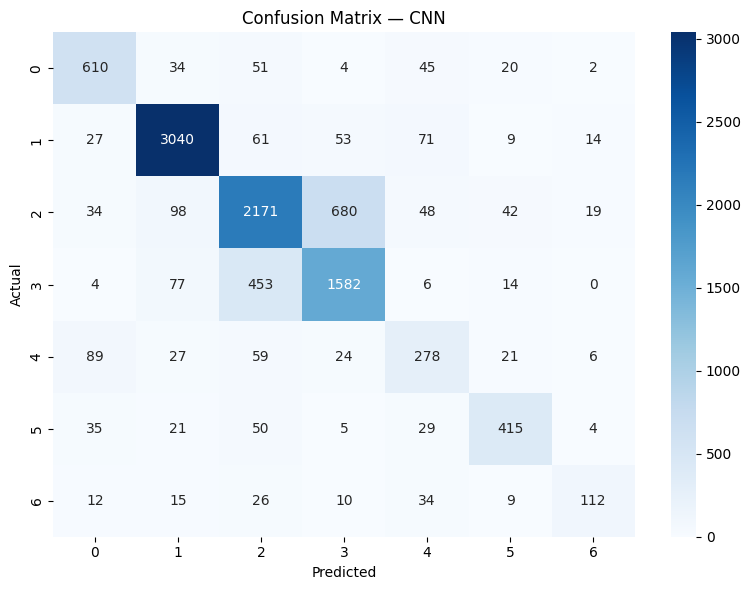

Macro AUC: 0.9555  95% CI [0.9526, 0.9584]
Saved → outputs/01_OriginalLabel/CNN_roc_curve.png


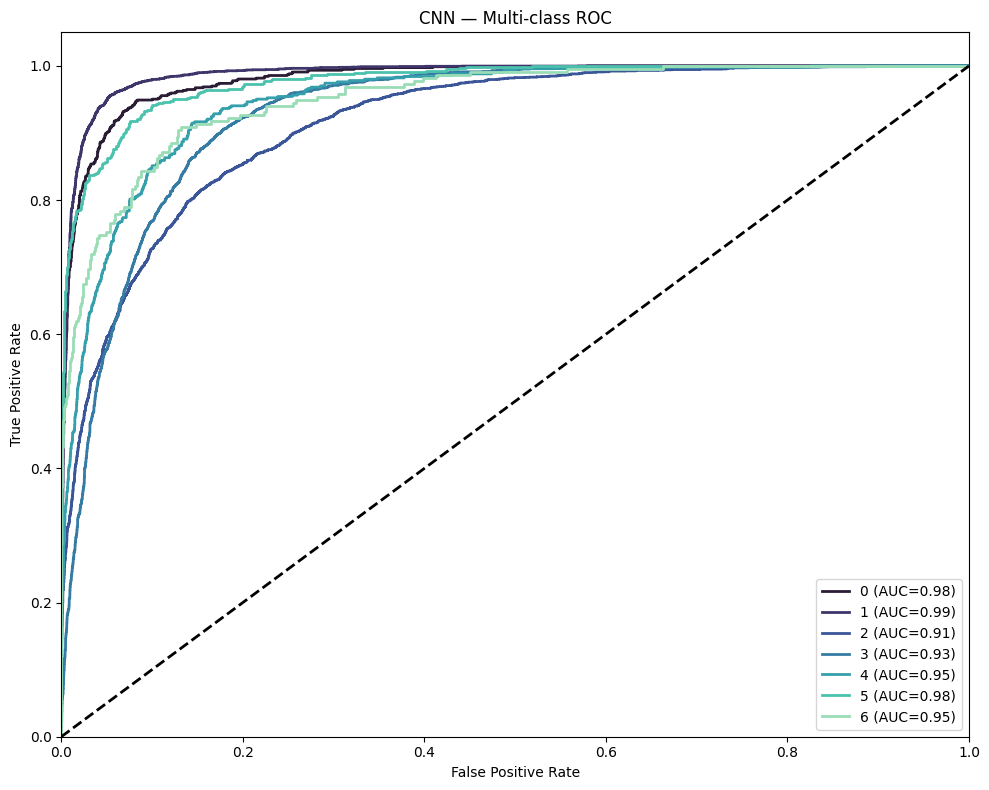

In [ ]:
cnn_preds, cnn_probs, y_true_cnn = evaluate_pytorch(
    best_cnn, test_loader_seq, label_encoder, "CNN", use_attention_mask=False
)

## 4.2 Transformer

### 4.2.1 Generic transformer train function

In [ ]:
def dropout_report(module):
    """Map every instantiated nn.Dropout to its probability.

    Reporting the full named map avoids guessing which layer matters: ALBERT's
    backbone dropout is 0.0 while its classifier dropout carries the sampled
    value, and the aspect head's dropout is separate from the encoder's.
    """
    report = {}
    for name, m in module.named_modules():
        if isinstance(m, nn.Dropout):
            report[name or "<root>"] = float(m.p)
    return report


def sampled_dropout_effective(module):
    """The dropout the sampled hyperparameter is meant to control.

    In AlbertForSequenceClassification the classifier dropout module is the
    top-level ``dropout`` (the backbone's own dropout is 0.0), so prefer the
    shallowest module whose name ends in "dropout"; fall back to the deepest
    encoder dropout only if no top-level one exists.
    """
    report = dropout_report(module)
    if not report:
        return None
    named = sorted(report.items(), key=lambda kv: (kv[0].count("."), len(kv[0])))
    for name, p in named:
        if "classifier" in name.lower():
            return p
    for name, p in named:
        if name.split(".")[-1].lower() == "dropout":
            return p
    return named[0][1]

def train_transformer(model, train_loader, val_loader,
                      lr=2e-5, max_epochs=6, patience=2):
    """Fine-tune a HuggingFace transformer with FP16, grad clip, OneCycleLR."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
                with autocast("cuda", enabled=USE_FP16):
                    out = model(input_ids=ids, attention_mask=mask)
                logits = out.logits if hasattr(out, "logits") else out
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["label"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            raw = model._orig_mod if hasattr(model, "_orig_mod") else model
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    raw = model._orig_mod if hasattr(model, "_orig_mod") else model
    if best_state:
        raw.load_state_dict(best_state)
    return best_f1, raw

### 4.2.2 ALBERT

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for ALBERT...")
albert_tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")


def batch_tokenize(texts, tokenizer, max_len, batch_size=512):
    all_ids, all_masks = [], []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size], max_length=max_len,
            truncation=True, padding="max_length", return_tensors="pt",
        )
        all_ids.append(enc["input_ids"])
        all_masks.append(enc["attention_mask"])
    return torch.cat(all_ids), torch.cat(all_masks)


# Use same text lists as DL
train_ids_albert, train_masks_albert = batch_tokenize(train_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_albert, val_masks_albert     = batch_tokenize(val_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_albert, test_masks_albert   = batch_tokenize(test_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
print(f"ALBERT tokens: train={train_ids_albert.shape}")


# ── Cached dataset for transformers ──────────────────────
class TransformerDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(np.asarray(labels, dtype=np.int64))

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label": self.labels[idx],
        }


_tf_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

train_loader_albert = DataLoader(
    TransformerDataset(train_ids_albert, train_masks_albert, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_albert = DataLoader(
    TransformerDataset(val_ids_albert, val_masks_albert, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_albert = DataLoader(
    TransformerDataset(test_ids_albert, test_masks_albert, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for ALBERT...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

ALBERT tokens: train=torch.Size([31976, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning ALBERT...")
    start = time.time()

    albert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*albert_param_space["lr"])),
            "epochs": int(np.random.randint(*albert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*albert_param_space["dropout"])),
        }

        model = AlbertForSequenceClassification.from_pretrained(
            "albert-base-v2", num_labels=NUM_CLASSES,
            classifier_dropout_prob=hp["dropout"],
        )
        hp["dropout_modules"] = dropout_report(model)
        hp["effective_dropout"] = sampled_dropout_effective(model)

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")
    with open(MODEL_PATHS["albert"]["params"], "w") as _f:
        json.dump(best_params_albert, _f, indent=2)
    print(f"Saved params -> {MODEL_PATHS['albert']['params']}")

    torch.save(best_albert.state_dict(), MODEL_PATHS["albert"]["model"])

    with open(MODEL_PATHS["albert"]["params"], "w") as _pf:

        json.dump(best_params_albert, _pf, indent=2)
else:
    print("Loading ALBERT from disk...")
    with open(MODEL_PATHS["albert"]["params"]) as _f:
        best_params_albert = json.load(_f)
    best_albert = AlbertForSequenceClassification.from_pretrained(
        "albert-base-v2", num_labels=NUM_CLASSES,
        classifier_dropout_prob=best_params_albert["dropout"],
    )
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))
    print(f"Loaded ALBERT from {MODEL_PATHS['albert']['model']}")


Tuning ALBERT...


ALBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 47.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.3828 | Val F1=0.7011
  Epoch 2/9 | Loss=0.6911 | Val F1=0.7492
  Epoch 3/9 | Loss=0.5231 | Val F1=0.7793
  Epoch 4/9 | Loss=0.4914 | Val F1=0.6690
  Epoch 5/9 | Loss=0.4767 | Val F1=0.7867
  Epoch 6/9 | Loss=0.3401 | Val F1=0.7963
  Epoch 7/9 | Loss=0.2600 | Val F1=0.7977
  Epoch 8/9 | Loss=0.2084 | Val F1=0.8069
  Epoch 9/9 | Loss=0.1872 | Val F1=0.8040


ALBERT Random Search: 100%|██████████| 10/10 [1:00:36<00:00, 363.61s/it]

ALBERT tuning: 3636.1s | Best F1=0.8069
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563, 'dropout_modules': {'albert.embeddings.dropout': 0.0, 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.attention_dropout': 0.0, 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.output_dropout': 0.0, 'albert.encoder.albert_layer_groups.0.albert_layers.0.dropout': 0.0, 'dropout': 0.2365358833708563}, 'effective_dropout': 0.2365358833708563}
Saved params -> outputs/01_OriginalLabel/best_albert_params.json


#### Step 3: Model Evaluation

Eval ALBERT: 100%|██████████| 83/83 [00:06<00:00, 11.98it/s]



Evaluation: ALBERT
                      precision    recall  f1-score   support

             Anxiety     0.8284    0.8381    0.8332       766
              Normal     0.9414    0.9365    0.9389      3275
          Depression     0.7800    0.7248    0.7514      3092
            Suicidal     0.6994    0.7570    0.7271      2136
              Stress     0.6593    0.7063    0.6820       504
             Bipolar     0.7866    0.8175    0.8018       559
Personality disorder     0.6540    0.6330    0.6434       218

            accuracy                         0.8074     10550
           macro avg     0.7641    0.7733    0.7682     10550
        weighted avg     0.8093    0.8074    0.8077     10550

Weighted F1: 0.8077  95% CI [0.8003, 0.8147]
Macro F1:    0.7682  95% CI [0.7558, 0.7800]
Saved → outputs/01_OriginalLabel/ALBERT_confusion_matrix.png


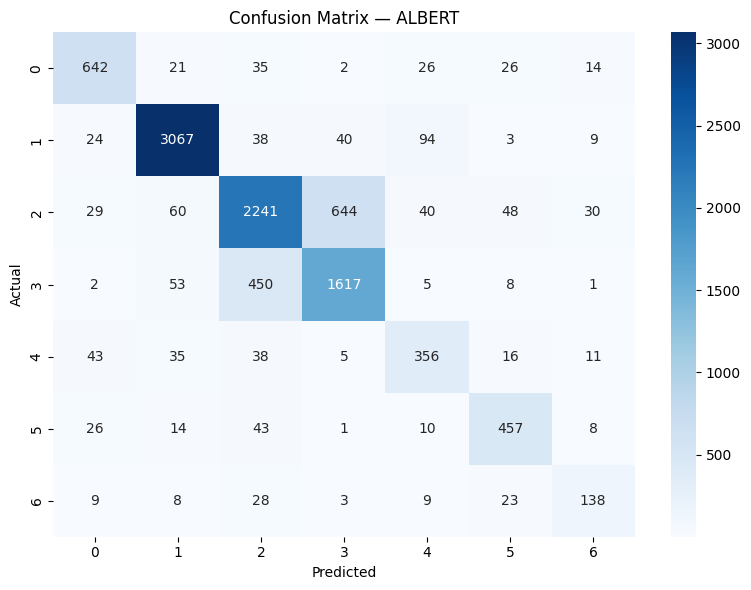

Macro AUC: 0.9649  95% CI [0.9623, 0.9675]
Saved → outputs/01_OriginalLabel/ALBERT_roc_curve.png


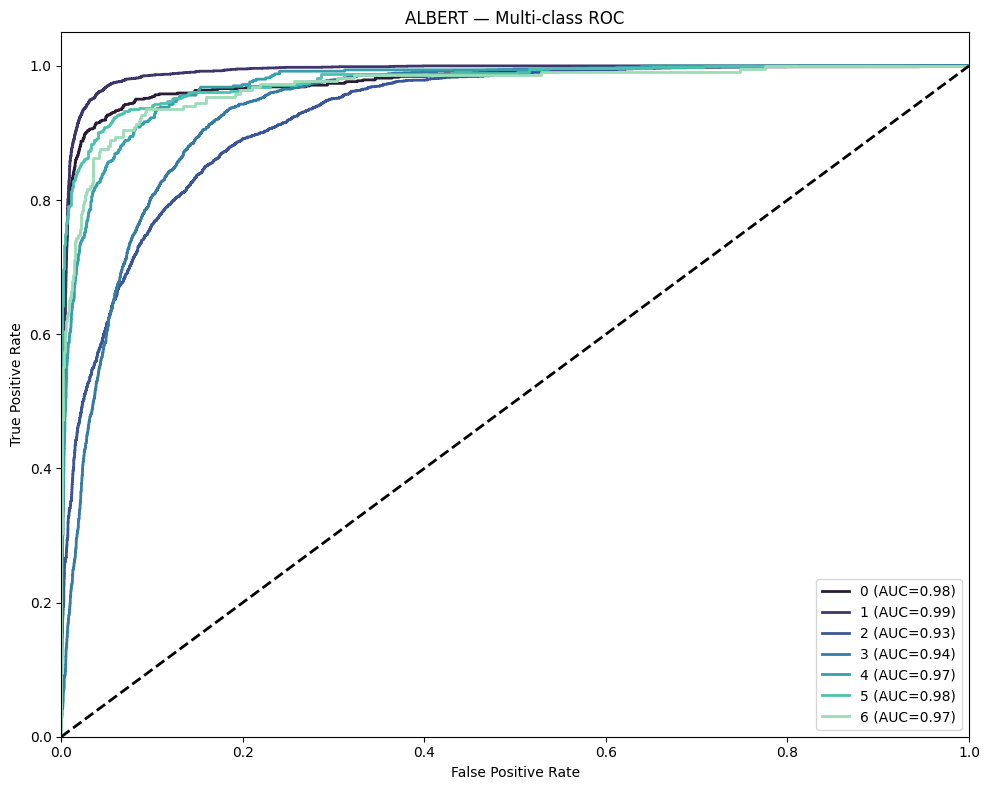

In [ ]:
albert_preds, albert_probs, y_true_albert = evaluate_pytorch(
    best_albert, test_loader_albert, label_encoder, "ALBERT", use_attention_mask=True
)

### 4.4.3 BioBERT Modeling

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for BioBERT...")
biobert_name = "dmis-lab/biobert-v1.1"
biobert_tokenizer = AutoTokenizer.from_pretrained(biobert_name)

train_ids_bio, train_masks_bio = batch_tokenize(train_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_bio, val_masks_bio     = batch_tokenize(val_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_bio, test_masks_bio   = batch_tokenize(test_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
print(f"BioBERT tokens: train={train_ids_bio.shape}")

train_loader_biobert = DataLoader(
    TransformerDataset(train_ids_bio, train_masks_bio, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_biobert = DataLoader(
    TransformerDataset(val_ids_bio, val_masks_bio, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_biobert = DataLoader(
    TransformerDataset(test_ids_bio, test_masks_bio, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for BioBERT...


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

BioBERT tokens: train=torch.Size([31976, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning BioBERT...")
    start = time.time()

    biobert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_biobert, best_params_biobert, best_biobert = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*biobert_param_space["lr"])),
            "epochs": int(np.random.randint(*biobert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*biobert_param_space["dropout"])),
        }

        biobert_config = AutoConfig.from_pretrained(
            biobert_name, num_labels=NUM_CLASSES,
        )
        # Dropout must be set on the config BEFORE instantiation, otherwise the
        # already-constructed nn.Dropout modules keep the pretrained default and
        # the sampled value never takes effect (the R0 behaviour).
        biobert_config.hidden_dropout_prob = hp["dropout"]
        biobert_config.attention_probs_dropout_prob = hp["dropout"]

        model = AutoModelForSequenceClassification.from_pretrained(
            biobert_name, config=biobert_config,
        )
        hp["dropout_modules"] = dropout_report(model)
        hp["effective_dropout"] = sampled_dropout_effective(model)

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")
    with open(MODEL_PATHS["biobert"]["params"], "w") as _f:
        json.dump(best_params_biobert, _f, indent=2)
    print(f"Saved params -> {MODEL_PATHS['biobert']['params']}")

    torch.save(best_biobert.state_dict(), MODEL_PATHS["biobert"]["model"])

    with open(MODEL_PATHS["biobert"]["params"], "w") as _pf:

        json.dump(best_params_biobert, _pf, indent=2)
else:
    print("Loading BioBERT from disk...")
    with open(MODEL_PATHS["biobert"]["params"]) as _f:
        best_params_biobert = json.load(_f)
    biobert_config = AutoConfig.from_pretrained(biobert_name, num_labels=NUM_CLASSES)
    biobert_config.hidden_dropout_prob = best_params_biobert["dropout"]
    biobert_config.attention_probs_dropout_prob = best_params_biobert["dropout"]
    best_biobert = AutoModelForSequenceClassification.from_pretrained(
        biobert_name, config=biobert_config,
    )
    best_biobert.load_state_dict(torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE))
    print(f"Loaded BioBERT from {MODEL_PATHS['biobert']['model']}")



Tuning BioBERT...


BioBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  433MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.5684 | Val F1=0.6547
  Epoch 2/9 | Loss=0.7593 | Val F1=0.6934
  Epoch 3/9 | Loss=0.5877 | Val F1=0.7626
  Epoch 4/9 | Loss=0.4990 | Val F1=0.7573
  Epoch 5/9 | Loss=0.4270 | Val F1=0.7706
  Epoch 6/9 | Loss=0.3729 | Val F1=0.7914
  Epoch 7/9 | Loss=0.3397 | Val F1=0.7802
  Epoch 8/9 | Loss=0.3165 | Val F1=0.7874
  Epoch 9/9 | Loss=0.3108 | Val F1=0.7867
  Early stopping at epoch 9.


BioBERT Random Search: 100%|██████████| 10/10 [46:16<00:00, 277.64s/it]


BioBERT tuning: 2776.4s | Best F1=0.7946
Best params: {'lr': 1.7871371577780496e-05, 'epochs': 5, 'dropout': 0.0007927791888235614, 'dropout_modules': {'bert.embeddings.dropout': 0.0007927791888235614, 'bert.encoder.layer.0.attention.self.dropout': 0.0007927791888235614, 'bert.encoder.layer.0.attention.output.dropout': 0.0007927791888235614, 'bert.encoder.layer.0.output.dropout': 0.0007927791888235614, 'bert.encoder.layer.1.attention.self.dropout': 0.0007927791888235614, 'bert.encoder.layer.1.attention.output.dropout': 0.0007927791888235614, 'bert.encoder.layer.1.output.dropout': 0.0007927791888235614, 'bert.encoder.layer.2.attention.self.dropout': 0.0007927791888235614, 'bert.encoder.layer.2.attention.output.dropout': 0.0007927791888235614, 'bert.encoder.layer.2.output.dropout': 0.0007927791888235614, 'bert.encoder.layer.3.attention.self.dropout': 0.0007927791888235614, 'bert.encoder.layer.3.attention.output.dropout': 0.0007927791888235614, 'bert.encoder.layer.3.output.dropout': 0.000

#### Step 3: Model Evaluation

Eval BioBERT: 100%|██████████| 83/83 [00:03<00:00, 23.56it/s]



Evaluation: BioBERT
                      precision    recall  f1-score   support

             Anxiety     0.8088    0.8616    0.8344       766
              Normal     0.9416    0.9304    0.9360      3275
          Depression     0.7772    0.7177    0.7463      3092
            Suicidal     0.6864    0.7154    0.7006      2136
              Stress     0.5853    0.7282    0.6490       504
             Bipolar     0.8312    0.8014    0.8160       559
Personality disorder     0.5578    0.6422    0.5970       218

            accuracy                         0.7971     10550
           macro avg     0.7412    0.7710    0.7542     10550
        weighted avg     0.8013    0.7971    0.7983     10550

Weighted F1: 0.7983  95% CI [0.7904, 0.8056]
Macro F1:    0.7542  95% CI [0.7416, 0.7652]
Saved → outputs/01_OriginalLabel/BioBERT_confusion_matrix.png


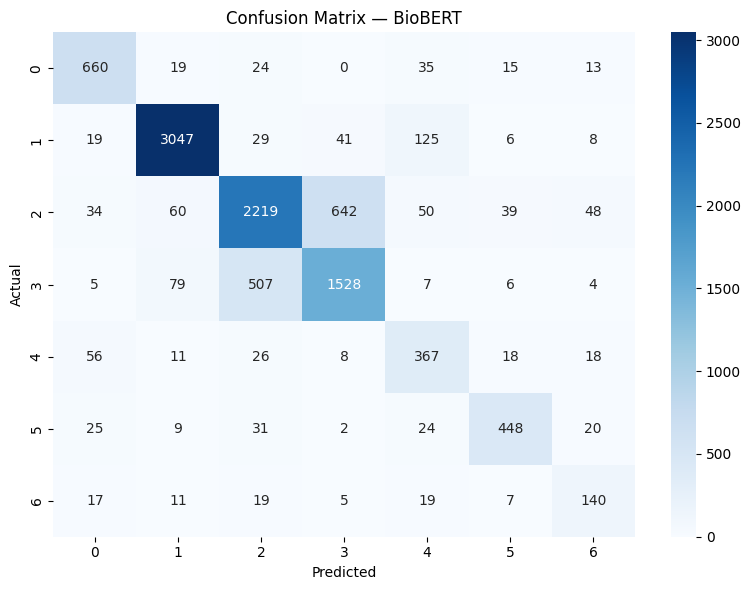

Macro AUC: 0.9655  95% CI [0.9630, 0.9680]
Saved → outputs/01_OriginalLabel/BioBERT_roc_curve.png


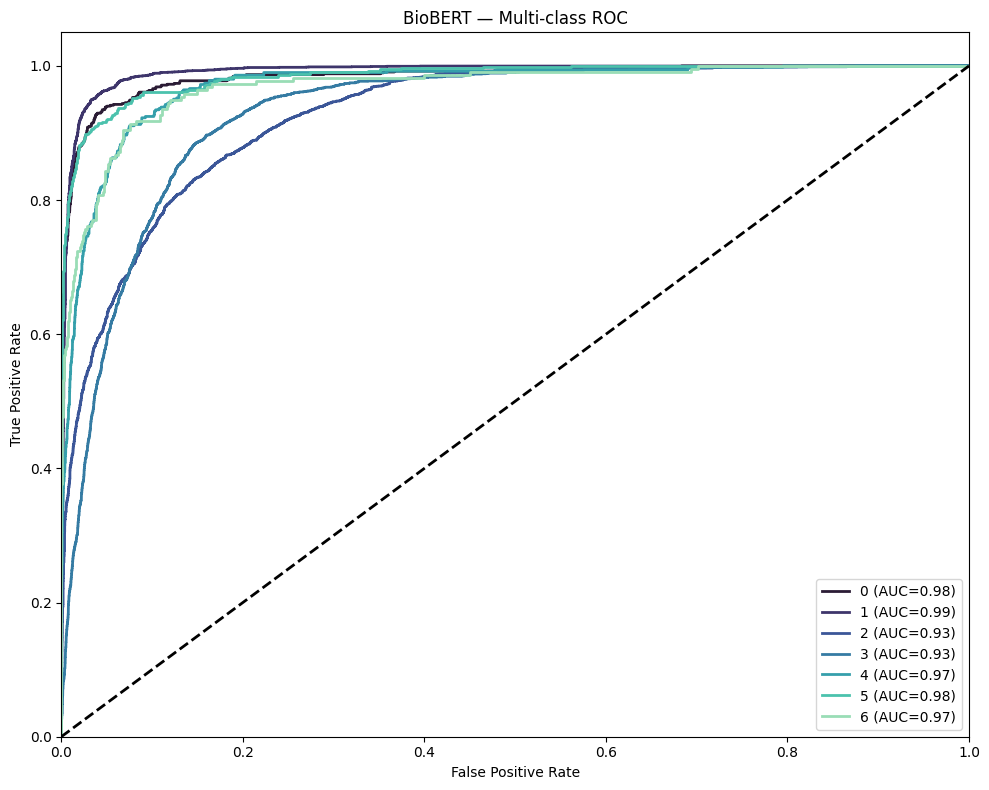

In [ ]:
biobert_preds, biobert_probs, y_true_biobert = evaluate_pytorch(
    best_biobert, test_loader_biobert, label_encoder, "BioBERT", use_attention_mask=True
)

## 4.3 Save Predictions for DL models

In [ ]:
print("\nSaving DL predictions...")

# Verify all DL models evaluated on same test set
assert np.array_equal(y_true_gru, y_true_cnn)
assert np.array_equal(y_true_gru, y_true_albert)
assert np.array_equal(y_true_gru, y_true_biobert)
y_true_dl = y_true_gru

true_names = label_encoder.inverse_transform(y_true_dl)

if "id" in df_test_dl.columns:
    df_pred_dl = df_test_dl[["id", TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
else:
    df_pred_dl = df_test_dl[[TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
    df_pred_dl.insert(0, "id", df_test_dl.index)

df_pred_dl = df_pred_dl.rename(columns={TEXT_COLUMN: "text", LABEL_COLUMN_ENCODED: "true_label_id"})
df_pred_dl["true_label"] = true_names

for name, preds, probs in [
    ("gru", gru_preds, gru_probs),
    ("cnn", cnn_preds, cnn_probs),
    ("albert", albert_preds, albert_probs),
    ("biobert", biobert_preds, biobert_probs),
]:
    df_pred_dl[f"{name}_pred_id"] = preds
    df_pred_dl[f"{name}_pred"] = label_encoder.inverse_transform(preds)
    for i, cls in enumerate(label_encoder.classes_):
        df_pred_dl[f"{name}_prob_{cls}"] = probs[:, i]

dl_pred_path = OUTPUT_PATH / "dl_models_predictions.csv"
df_pred_dl.to_csv(dl_pred_path, index=False)
print(f"Saved DL predictions → {dl_pred_path}")


Saving DL predictions...
Saved DL predictions → outputs/01_OriginalLabel/dl_models_predictions.csv


# 5. Model Comparison

In [33]:
print("\n" + "="*60)
print("MODEL COMPARISON — McNemar Pairwise Tests")
print("="*60)

# Load both prediction files
df_ml_pred = pd.read_csv(OUTPUT_PATH / "ml_models_predictions.csv")
df_dl_pred = pd.read_csv(OUTPUT_PATH / "dl_models_predictions.csv")

df_merged = pd.merge(df_ml_pred, df_dl_pred, on=["id", "true_label", "true_label_id"],
                     suffixes=("_ml", "_dl"))
print(f"Merged: {df_merged.shape[0]} rows")

y_true_all = df_merged["true_label_id"].values

# Build prediction dict
model_preds_all = {
    "LR":      label_encoder.transform(df_merged["lr_pred"].values),
    "SVM":     label_encoder.transform(df_merged["svm_pred"].values),  # <-- add this
    "RF":      label_encoder.transform(df_merged["rf_pred"].values),
    "LGBM":    label_encoder.transform(df_merged["lgbm_pred"].values),
    "GRU":     df_merged["gru_pred_id"].values,
    "CNN":     df_merged["cnn_pred_id"].values,
    "ALBERT":  df_merged["albert_pred_id"].values,
    "BioBERT": df_merged["biobert_pred_id"].values,
}

# Verify lengths
for name, arr in model_preds_all.items():
    assert len(arr) == len(y_true_all), f"{name} length mismatch"


def mcnemar_pairwise(y_true, model_preds, method="bonferroni"):
    y_true = np.asarray(y_true)
    names = list(model_preds.keys())
    results = []

    for m1, m2 in combinations(names, 2):
        y1, y2 = np.asarray(model_preds[m1]), np.asarray(model_preds[m2])
        c1 = (y1 == y_true)
        c2 = (y2 == y_true)

        a = np.sum(c1 & c2)
        b = np.sum(c1 & ~c2)
        c = np.sum(~c1 & c2)
        d = np.sum(~c1 & ~c2)

        res = mcnemar(np.array([[a, b], [c, d]]), exact=False, correction=True)
        p = res.pvalue

        if p >= 0.05:
            winner = "Inconclusive"
        elif b > c:
            winner = f"{m1} > {m2}"
        elif c > b:
            winner = f"{m2} > {m1}"
        else:
            winner = "Tie"

        results.append({
            "Model_1": m1, "Model_2": m2,
            "both_correct": a, "m1_only": b, "m2_only": c, "both_wrong": d,
            "statistic": res.statistic, "p_raw": p, "winner_raw": winner,
        })

    raw_p = [r["p_raw"] for r in results]
    _, corrected_p, _, _ = multipletests(raw_p, method=method)

    for i, pc in enumerate(corrected_p):
        results[i]["p_corrected"] = pc
        results[i]["significant"] = "Yes" if pc < 0.05 else "No"

    df_res = pd.DataFrame(results)
    print(f"\nPairwise McNemar Tests (corrected: {method}):")
    print(df_res.to_string(index=False))
    return df_res


df_mcnemar = mcnemar_pairwise(y_true_all, model_preds_all)

# Save
mcnemar_path = OUTPUT_PATH / "mcnemar_results.csv"
df_mcnemar.to_csv(mcnemar_path, index=False)
print(f"\nSaved McNemar results → {mcnemar_path}")

print("\n✓ Pipeline complete.")


MODEL COMPARISON — McNemar Pairwise Tests
Merged: 10550 rows

Pairwise McNemar Tests (corrected: bonferroni):
Model_1 Model_2  both_correct  m1_only  m2_only  both_wrong  statistic        p_raw       winner_raw  p_corrected significant
     LR     SVM          7714      294      319        2223   0.939641 3.323702e-01     Inconclusive 1.000000e+00          No
     LR      RF          7030      978      831        1711  11.783306 5.976426e-04          LR > RF 1.673399e-02         Yes
     LR    LGBM          7455      553      700        1842  17.011971 3.714488e-05        LGBM > LR 1.040057e-03         Yes
     LR     GRU          6924     1084     1063        1479   0.186306 6.660087e-01     Inconclusive 1.000000e+00          No
     LR     CNN          7249      759      959        1583  23.050640 1.577900e-06         CNN > LR 4.418119e-05         Yes
     LR  ALBERT          7279      729     1239        1303 131.646850 1.787500e-30      ALBERT > LR 5.005001e-29         Yes
     LR